# Exploring TCM impact on predicted masks

Compare two trained experiments on the same test set. The notebook loads each experiment config/checkpoint, runs direct EMA segmentation inference, computes per-example Dice/IoU, plots best and worst cases for each model with predicted-vs-label overlays, and analyzes which examples improved or regressed.

In [1]:
# Edit these two experiment names before running the notebook.
notebook_config = {
    "experiment_names": [
        "2026-05-23T19-49-45_teste-target-c2-c4",
        "2026-05-12T20-08-54_vfss-new-inca-window-3",
    ],
    "logs_dir": "../logs",
    "checkpoint": "best",  # "best", "last", or an explicit .ckpt path per experiment in checkpoint_paths
    "checkpoint_paths": {},
    "batch_size": 1,
    "num_workers": 0,
    "seed": 42,
    "max_examples": None,  # set to a small int for a quick smoke test
    "top_k": 5,
    "comparison_metric": "dice",  # "dice" or "iou"
}

assert len(notebook_config["experiment_names"]) == 2, "This notebook compares exactly two experiments."

In [2]:
import os
import sys
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
from einops import rearrange
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from omegaconf import OmegaConf, DictConfig, ListConfig
from pytorch_lightning import seed_everything
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ldm.util import instantiate_from_config
from scripts.slice2seg import load_model_from_config

/home/caioseda/miniconda3/envs/sdseg-cpython/lib/python3.9/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Experiment loading

The helper below loads the project YAML saved under each experiment folder, strips pretraining `ckpt_path` entries so the trained checkpoint is the only restored state, and selects either the best or last checkpoint.

In [3]:
def remove_key_recursively(node, key):
    if isinstance(node, DictConfig):
        for child_key in list(node.keys()):
            if child_key == key:
                node.pop(child_key)
            else:
                remove_key_recursively(node[child_key], key)
    elif isinstance(node, ListConfig):
        for value in node:
            remove_key_recursively(value, key)


def load_experiment_config(experiment_folder):
    config_folder = experiment_folder / "configs"
    project_config_files = sorted(config_folder.glob("*-project.yaml"))
    if len(project_config_files) != 1:
        raise FileNotFoundError(
            f"Expected exactly one *-project.yaml in {config_folder}, found {len(project_config_files)}."
        )

    config = OmegaConf.load(project_config_files[0])
    remove_key_recursively(config.model.params, "ckpt_path")
    return config, project_config_files[0]


def choose_checkpoint(experiment_folder, checkpoint="best", checkpoint_paths=None):
    checkpoint_paths = checkpoint_paths or {}
    experiment_name = experiment_folder.name
    if experiment_name in checkpoint_paths:
        ckpt_path = Path(checkpoint_paths[experiment_name]).expanduser()
        if not ckpt_path.is_absolute():
            ckpt_path = (experiment_folder / ckpt_path).resolve()
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Checkpoint path does not exist: {ckpt_path}")
        return ckpt_path

    checkpoint_folder = experiment_folder / "checkpoints"
    if checkpoint == "last":
        ckpt_path = checkpoint_folder / "last.ckpt"
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Missing last checkpoint: {ckpt_path}")
        return ckpt_path

    if checkpoint != "best":
        ckpt_path = Path(checkpoint)
        if not ckpt_path.is_absolute():
            ckpt_path = (experiment_folder / ckpt_path).resolve()
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Checkpoint path does not exist: {ckpt_path}")
        return ckpt_path

    candidates = [path for path in checkpoint_folder.glob("*.ckpt") if path.name != "last.ckpt"]
    if candidates:
        return max(candidates, key=lambda path: path.stat().st_mtime)

    ckpt_path = checkpoint_folder / "last.ckpt"
    if ckpt_path.exists():
        return ckpt_path
    raise FileNotFoundError(f"No checkpoint found in {checkpoint_folder}")


def get_test_dataset(config):
    if "test" not in config.data.params:
        raise KeyError("Config has no data.params.test entry.")
    return instantiate_from_config(config.data.params.test)


def load_experiment(experiment_name, cfg):
    experiment_folder = Path(cfg["logs_dir"]) / experiment_name
    if not experiment_folder.exists():
        raise FileNotFoundError(f"Experiment folder does not exist: {experiment_folder}")

    config, project_config_path = load_experiment_config(experiment_folder)
    ckpt_path = choose_checkpoint(
        experiment_folder,
        checkpoint=cfg["checkpoint"],
        checkpoint_paths=cfg.get("checkpoint_paths"),
    )
    dataset = get_test_dataset(config)
    loader = DataLoader(
        dataset,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=torch.cuda.is_available(),
    )

    model, checkpoint_state = load_model_from_config(config, ckpt_path)
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    model = model.to(device).eval()

    window_size = OmegaConf.select(config, "data.params.test.params.window_size", default=None)
    stride = OmegaConf.select(config, "data.params.test.params.stride", default=None)

    return {
        "name": experiment_name,
        "folder": experiment_folder,
        "config": config,
        "project_config_path": project_config_path,
        "ckpt_path": ckpt_path,
        "checkpoint_state": checkpoint_state,
        "dataset": dataset,
        "loader": loader,
        "model": model,
        "device": device,
        "window_size": window_size,
        "stride": stride,
    }


experiments = [load_experiment(name, notebook_config) for name in notebook_config["experiment_names"]]

summary = pd.DataFrame([
    {
        "experiment": exp["name"],
        "model_target": OmegaConf.select(exp["config"], "model.target"),
        "checkpoint": str(exp["ckpt_path"]),
        "project_config": str(exp["project_config_path"]),
        "test_examples": len(exp["dataset"]),
        "window_size": exp["window_size"],
        "stride": exp["stride"],
    }
    for exp in experiments
])
display(summary)

Global Step: 54000
SDSeg: Running in eps-prediction mode
DiffusionWrapper has 294.97 M params.
Keeping EMAs of 522.
[Model Weights Rewrite]: Loading model from ../logs/2026-05-23T19-49-45_teste-target-c2-c4/checkpoints/epoch=380-step=53999.ckpt
missing keys:
[]
unexpected keys:
[]
Global Step: 82000
SDSeg: Running in eps-prediction mode
DiffusionWrapper has 294.97 M params.
Keeping EMAs of 522.
[Model Weights Rewrite]: Loading model from ../logs/2026-05-12T20-08-54_vfss-new-inca-window-3/checkpoints/epoch=577-step=81999.ckpt
missing keys:
[]
unexpected keys:
[]


,experiment,model_target,checkpoint,project_config,test_examples,window_size,stride
0,2026-05-23T19-49-45_teste-target-c2-c4,ldm.models.diffusion.videoSDSeg.SDSeg,../logs/2026-05-23T19-49-45_teste-target-c2-c4...,../logs/2026-05-23T19-49-45_teste-target-c2-c4...,161,3,1
1,2026-05-12T20-08-54_vfss-new-inca-window-3,ldm.models.diffusion.videoSDSeg.SDSeg,../logs/2026-05-12T20-08-54_vfss-new-inca-wind...,../logs/2026-05-12T20-08-54_vfss-new-inca-wind...,161,3,1


## Inference and metric helpers

These functions intentionally mirror the direct EMA inference used by `model.log_dice`, but they retain each prediction, label, center frame, and temporal window for case-level analysis.

In [4]:
def scalarize(value):
    if torch.is_tensor(value):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return value.detach().cpu().tolist()
    if isinstance(value, np.ndarray):
        if value.size == 1:
            return value.item()
        return value.tolist()
    if isinstance(value, (list, tuple)):
        if len(value) == 1:
            return scalarize(value[0])
        return [scalarize(item) for item in value]
    return value


def metric_scalar(value):
    value = scalarize(value)
    if isinstance(value, list):
        return float(np.mean(value))
    return float(value)


def parse_metadata(batch):
    metadata = batch.get("metadata", {})
    parsed = {}
    for key, value in metadata.items():
        parsed[key] = scalarize(value)
    if "window_frame_ids" in parsed and not isinstance(parsed["window_frame_ids"], list):
        parsed["window_frame_ids"] = [parsed["window_frame_ids"]]
    return parsed


def to_unit_image(image):
    image = np.asarray(image, dtype=np.float32)
    if image.ndim == 2:
        image = image[:, :, None]
    if image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=2)
    if image.shape[-1] > 3:
        image = image[:, :, :3]
    if image.min() < 0:
        image = (image + 1.0) / 2.0
    elif image.max() > 1.0:
        image = image / 255.0
    return np.clip(image, 0.0, 1.0)


def tensor_to_frames(image):
    if torch.is_tensor(image):
        image = image.detach().cpu()
    else:
        image = torch.as_tensor(image)

    if image.ndim >= 1 and image.shape[0] == 1:
        image = image[0]

    frames = []
    if image.ndim == 4:  # temporal window: T C H W or T H W C
        for frame in image:
            if frame.ndim == 3 and frame.shape[0] in [1, 3]:
                frame = rearrange(frame, "c h w -> h w c")
            frames.append(to_unit_image(frame.numpy()))
    elif image.ndim == 3:
        if image.shape[0] in [1, 3]:
            image = rearrange(image, "c h w -> h w c")
        frames.append(to_unit_image(image.numpy()))
    elif image.ndim == 2:
        frames.append(to_unit_image(image.numpy()))
    else:
        raise ValueError(f"Unsupported image shape for display: {tuple(image.shape)}")
    return frames


def label_to_2d(label):
    if torch.is_tensor(label):
        label = label.detach().cpu().numpy()
    label = np.asarray(label)
    if label.ndim == 4:
        label = label[0]
    if label.ndim == 3 and label.shape[0] in [1, 3]:
        label = rearrange(label, "c h w -> h w c")
    if label.ndim == 3:
        label = label[:, :, 0]
    return label.round().astype(int)


def prediction_to_2d(prediction):
    prediction = np.asarray(prediction)
    if prediction.ndim == 4:
        prediction = prediction[0]
    if prediction.ndim == 3:
        prediction = prediction[:, :, 0]
    return prediction.astype(bool)

## Run both models

This can take a while because predictions are retained for plotting. Use `max_examples` in the config cell for a fast smoke test.

In [5]:
def collect_experiment_results(exp, cfg):
    seed_everything(cfg["seed"])
    rows = []
    results = {}
    model = exp["model"]
    loader = exp["loader"]
    max_examples = cfg.get("max_examples")
    precision_scope = torch.autocast("cuda") if exp["device"].type == "cuda" else nullcontext()

    with torch.no_grad(), precision_scope:
        ema_scope = model.ema_scope(f"EMA direct inference: {exp['name']}") if hasattr(model, "ema_scope") else nullcontext()
        with ema_scope:
            for sample_index, batch in enumerate(tqdm(loader, desc=exp["name"])):
                if max_examples is not None and sample_index >= max_examples:
                    break
                if cfg["batch_size"] != 1:
                    raise ValueError("This notebook stores per-example predictions and expects batch_size=1.")

                metadata = parse_metadata(batch)
                file_path = scalarize(batch.get("file_path_", [None]))
                sample_id = metadata.get("video_frame") or file_path or f"sample_{sample_index}"

                output = model.predict_segmentation_batch(batch, use_direct=True, ddim_steps=50)
                prediction_2d = prediction_to_2d(output["prediction"])
                label_2d = label_to_2d(output["label"])
                row = {
                    "experiment": exp["name"],
                    "sample_id": sample_id,
                    "sample_index": sample_index,
                    "file_path": file_path,
                    "video_id": metadata.get("video_id"),
                    "frame_id": metadata.get("frame_id"),
                    "video_frame": metadata.get("video_frame"),
                    "selected_labeler": metadata.get("selected_labeler"),
                    "window_size": metadata.get("window_size", exp["window_size"]),
                    "stride": metadata.get("stride", exp["stride"]),
                    "window_frame_ids": metadata.get("window_frame_ids"),
                    "dice": metric_scalar(output["dice"]),
                    "iou": metric_scalar(output["iou"]),
                    "pred_area": int(prediction_2d.sum()),
                    "label_area": int((label_2d == 1).sum()),
                }
                rows.append(row)
                results[sample_id] = {
                    **row,
                    "prediction": prediction_2d,
                    "probabilities": to_unit_image(output["probabilities"]),
                    "label": label_2d,
                    "center_image": to_unit_image(output["image_for_log"]),
                    "frames": tensor_to_frames(batch["image"]),
                }

    return pd.DataFrame(rows), results


all_metric_frames = []
results_by_experiment = {}
for exp in experiments:
    metric_frame, result_dict = collect_experiment_results(exp, notebook_config)
    all_metric_frames.append(metric_frame)
    results_by_experiment[exp["name"]] = result_dict

metrics_df = pd.concat(all_metric_frames, ignore_index=True)
metric_summary_df = (
    metrics_df.groupby("experiment")[["dice", "iou", "pred_area", "label_area"]]
    .agg(["mean", "std", "min", "median", "max"])
    .round(4)
)

display(metrics_df.head())
display(metric_summary_df)

Global seed set to 42


EMA direct inference: 2026-05-23T19-49-45_teste-target-c2-c4: Switched to EMA weights


2026-05-23T19-49-45_teste-target-c2-c4:   0%|          | 0/161 [00:00<?, ?it/s]

Global seed set to 42


EMA direct inference: 2026-05-23T19-49-45_teste-target-c2-c4: Restored training weights
EMA direct inference: 2026-05-12T20-08-54_vfss-new-inca-window-3: Switched to EMA weights


2026-05-12T20-08-54_vfss-new-inca-window-3:   0%|          | 0/161 [00:00<?, ?it/s]

EMA direct inference: 2026-05-12T20-08-54_vfss-new-inca-window-3: Restored training weights


,experiment,sample_id,sample_index,file_path,video_id,frame_id,video_frame,selected_labeler,window_size,stride,window_frame_ids,dice,iou,pred_area,label_area
0,2026-05-23T19-49-45_teste-target-c2-c4,v109_f16,0,test/target_binary_c2_c4/v109_f16.tif,109,16,v109_f16,VC,3,1,"[15, 16, 17]",0.917135,0.846952,746,678
1,2026-05-23T19-49-45_teste-target-c2-c4,v109_f71,1,test/target_binary_c2_c4/v109_f71.tif,109,71,v109_f71,CS,3,1,"[70, 71, 72]",0.904636,0.825877,752,758
2,2026-05-23T19-49-45_teste-target-c2-c4,v109_f72,2,test/target_binary_c2_c4/v109_f72.tif,109,72,v109_f72,CS,3,1,"[71, 72, 73]",0.935806,0.879357,728,674
3,2026-05-23T19-49-45_teste-target-c2-c4,v109_f73,3,test/target_binary_c2_c4/v109_f73.tif,109,73,v109_f73,VC,3,1,"[72, 73, 74]",0.945704,0.897001,754,701
4,2026-05-23T19-49-45_teste-target-c2-c4,v117_f110,4,test/target_binary_c2_c4/v117_f110.tif,117,110,v117_f110,VR,3,1,"[109, 110, 111]",0.935013,0.877956,995,990


dice                          \
                                              mean     std     min  median   
experiment                                                                   
2026-05-12T20-08-54_vfss-new-inca-window-3  0.8720  0.0597  0.6285  0.8940   
2026-05-23T19-49-45_teste-target-c2-c4      0.8847  0.0769  0.5940  0.9115   

                                                       iou                  \
                                               max    mean     std     min   
experiment                                                                   
2026-05-12T20-08-54_vfss-new-inca-window-3  0.9389  0.7777  0.0894  0.4582   
2026-05-23T19-49-45_teste-target-c2-c4      0.9573  0.8006  0.1084  0.4225   

                                                            pred_area  \
                                            median     max       mean   
experiment                                                              
2026-05-12T20-08-54_vfss-new-inca-window-3  0.8084  0.8848  1464.4658   
2026-05-23T19-49-45_teste-target-c2-c4      0.8375  0.9182   681.7205   

                                                                         \
                                                 std  min  median   max   
experiment                                                                
2026-05-12T20-08-54_vfss-new-inca-window-3  391.9900  814  1415.0  2645   
2026-05-23T19-49-45_teste-target-c2-c4      179.6435  282   641.0  1249   

                                           label_area                         \
                                                 mean       std  min  median   
experiment                                                                     
2026-05-12T20-08-54_vfss-new-inca-window-3  1550.5404  511.2089  732  1472.0   
2026-05-23T19-49-45_teste-target-c2-c4       731.0870  213.0479  422   674.0   

                                                  
                                             max  
experiment                                        
2026-05-12T20-08-54_vfss-new-inca-window-3  3546  
2026-05-23T19-49-45_teste-target-c2-c4      1349

## Build comparison dataframe

The comparison is keyed by `video_frame` when available, otherwise by `file_path`. Positive deltas mean the second experiment improved over the first one listed in `notebook_config`.

In [6]:
base_exp, candidate_exp = notebook_config["experiment_names"]

wide = metrics_df.pivot(index="sample_id", columns="experiment", values=["dice", "iou", "pred_area", "label_area"])
comparison_df = pd.DataFrame(index=wide.index)
for metric in ["dice", "iou", "pred_area", "label_area"]:
    comparison_df[f"{metric}_{base_exp}"] = wide[(metric, base_exp)]
    comparison_df[f"{metric}_{candidate_exp}"] = wide[(metric, candidate_exp)]
    comparison_df[f"delta_{metric}"] = comparison_df[f"{metric}_{candidate_exp}"] - comparison_df[f"{metric}_{base_exp}"]

metadata_cols = ["sample_id", "sample_index", "file_path", "video_id", "frame_id", "video_frame", "selected_labeler", "label_area"]
metadata_df = metrics_df[metrics_df["experiment"] == base_exp][metadata_cols].drop_duplicates("sample_id").set_index("sample_id")
comparison_df = comparison_df.join(metadata_df, how="left")
comparison_df = comparison_df.reset_index()

metric = notebook_config["comparison_metric"]
comparison_summary = {
    "base_experiment": base_exp,
    "candidate_experiment": candidate_exp,
    f"mean_delta_{metric}": comparison_df[f"delta_{metric}"].mean(),
    f"median_delta_{metric}": comparison_df[f"delta_{metric}"].median(),
    "improved_examples": int((comparison_df[f"delta_{metric}"] > 0).sum()),
    "unchanged_examples": int((comparison_df[f"delta_{metric}"] == 0).sum()),
    "worse_examples": int((comparison_df[f"delta_{metric}"] < 0).sum()),
    "compared_examples": int(comparison_df[f"delta_{metric}"].notna().sum()),
}

display(pd.DataFrame([comparison_summary]))
display(comparison_df.sort_values(f"delta_{metric}").head(notebook_config["top_k"]))
display(comparison_df.sort_values(f"delta_{metric}", ascending=False).head(notebook_config["top_k"]))

,base_experiment,candidate_experiment,mean_delta_dice,median_delta_dice,improved_examples,unchanged_examples,worse_examples,compared_examples
0,2026-05-23T19-49-45_teste-target-c2-c4,2026-05-12T20-08-54_vfss-new-inca-window-3,-0.012705,-0.01048,57,0,104,161


,sample_id,dice_2026-05-23T19-49-45_teste-target-c2-c4,dice_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_dice,iou_2026-05-23T19-49-45_teste-target-c2-c4,iou_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_iou,pred_area_2026-05-23T19-49-45_teste-target-c2-c4,pred_area_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_pred_area,label_area_2026-05-23T19-49-45_teste-target-c2-c4,label_area_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_label_area,sample_index,file_path,video_id,frame_id,video_frame,selected_labeler,label_area
150,v86_f155,0.872906,0.628481,-0.244425,0.774476,0.458238,-0.316238,495.0,933.0,438.0,520.0,970.0,450.0,150,test/target_binary_c2_c4/v86_f155.tif,86,155,v86_f155,BB,520
87,v234_f188,0.926641,0.723958,-0.202683,0.863309,0.567347,-0.295962,535.0,1701.0,1166.0,501.0,987.0,486.0,87,test/target_binary_c2_c4/v234_f188.tif,234,188,v234_f188,BB,501
25,v131_f11,0.920398,0.751768,-0.168630,0.852535,0.602266,-0.250269,577.0,1586.0,1009.0,629.0,1101.0,472.0,25,test/target_binary_c2_c4/v131_f11.tif,131,11,v131_f11,VC,629
92,v23_f134,0.905080,0.745202,-0.159878,0.826618,0.593882,-0.232735,711.0,1979.0,1268.0,785.0,1408.0,623.0,92,test/target_binary_c2_c4/v23_f134.tif,23,134,v23_f134,VC,785
152,v86_f2,0.838649,0.701166,-0.137484,0.722132,0.539842,-0.182290,542.0,879.0,337.0,524.0,1266.0,742.0,152,test/target_binary_c2_c4/v86_f2.tif,86,2,v86_f2,VR,524


,sample_id,dice_2026-05-23T19-49-45_teste-target-c2-c4,dice_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_dice,iou_2026-05-23T19-49-45_teste-target-c2-c4,iou_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_iou,pred_area_2026-05-23T19-49-45_teste-target-c2-c4,pred_area_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_pred_area,label_area_2026-05-23T19-49-45_teste-target-c2-c4,label_area_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_label_area,sample_index,file_path,video_id,frame_id,video_frame,selected_labeler,label_area
130,v59_f102,0.623068,0.924138,0.301070,0.452504,0.858974,0.406470,282.0,814.0,532.0,559.0,781.0,222.0,130,test/target_binary_c2_c4/v59_f102.tif,59,102,v59_f102,VR,559
131,v59_f158,0.633615,0.897172,0.263557,0.463717,0.813520,0.349803,304.0,824.0,520.0,523.0,732.0,209.0,131,test/target_binary_c2_c4/v59_f158.tif,59,158,v59_f158,VR,523
154,v89_f118,0.662829,0.917966,0.255137,0.495695,0.848371,0.352676,463.0,1478.0,1015.0,753.0,1472.0,719.0,154,test/target_binary_c2_c4/v89_f118.tif,89,118,v89_f118,VC,753
107,v30_f80,0.685327,0.937207,0.251881,0.521290,0.881834,0.360544,420.0,1108.0,688.0,759.0,1026.0,267.0,107,test/target_binary_c2_c4/v30_f80.tif,30,80,v30_f80,CS,759
105,v30_f15,0.667208,0.904476,0.237268,0.500609,0.825611,0.325002,451.0,1102.0,651.0,781.0,1065.0,284.0,105,test/target_binary_c2_c4/v30_f15.tif,30,15,v30_f15,AM,781


## Plotting helpers

Overlay colors:

- green: label only
- magenta: prediction only
- yellow: prediction and label overlap

In [7]:
def overlay_prediction_label(image, prediction, label, alpha=0.55):
    base = to_unit_image(image).copy()
    pred = prediction_to_2d(prediction)
    target = label_to_2d(label) == 1

    overlay = base.copy()
    label_only = target & ~pred
    pred_only = pred & ~target
    overlap = pred & target

    overlay[label_only] = (1 - alpha) * overlay[label_only] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[pred_only] = (1 - alpha) * overlay[pred_only] + alpha * np.array([1.0, 0.0, 1.0])
    overlay[overlap] = (1 - alpha) * overlay[overlap] + alpha * np.array([1.0, 1.0, 0.0])
    return np.clip(overlay, 0.0, 1.0)


def plot_sample(sample_id, results_by_experiment, experiment_names=None, title=None):
    experiment_names = experiment_names or list(results_by_experiment.keys())
    available = [name for name in experiment_names if sample_id in results_by_experiment[name]]
    if not available:
        raise KeyError(f"Sample {sample_id!r} is not available in any experiment result.")

    max_window = max(len(results_by_experiment[name][sample_id]["frames"]) for name in available)
    n_extra_cols = 3
    n_cols = max_window + n_extra_cols
    fig, axes = plt.subplots(
        len(available),
        n_cols,
        figsize=(3.0 * n_cols, 3.2 * len(available)),
        squeeze=False,
    )

    for row_idx, name in enumerate(available):
        result = results_by_experiment[name][sample_id]
        frames = result["frames"]
        frame_ids = result.get("window_frame_ids") or list(range(len(frames)))

        for col_idx in range(max_window):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx < len(frames):
                ax.imshow(frames[col_idx], cmap="gray")
                frame_label = frame_ids[col_idx] if col_idx < len(frame_ids) else col_idx
                center_marker = " *" if col_idx == len(frames) // 2 else ""
                ax.set_title(f"frame {frame_label}{center_marker}", fontsize=9)

        label_img = (result["label"] == 1).astype(float)
        pred_img = result["prediction"].astype(float)
        overlay_img = overlay_prediction_label(result["center_image"], result["prediction"], result["label"])

        for ax, img, col_title, cmap in [
            (axes[row_idx, max_window], label_img, "label", "gray"),
            (axes[row_idx, max_window + 1], pred_img, "prediction", "gray"),
            (axes[row_idx, max_window + 2], overlay_img, "overlay", None),
        ]:
            ax.axis("off")
            ax.imshow(img, cmap=cmap)
            ax.set_title(col_title, fontsize=9)

        axes[row_idx, 0].set_ylabel(
            f"{name}\nDice={result['dice']:.3f} IoU={result['iou']:.3f}",
            rotation=0,
            ha="right",
            va="center",
            fontsize=9,
        )

    if title:
        fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


def plot_ranked_cases(metrics_df, results_by_experiment, experiment_name, metric="dice", top_k=5):
    exp_metrics = metrics_df[metrics_df["experiment"] == experiment_name]
    ranked_groups = {
        f"Best {metric}: {experiment_name}": exp_metrics.nlargest(top_k, metric),
        f"Worst {metric}: {experiment_name}": exp_metrics.nsmallest(top_k, metric),
    }
    for group_title, frame in ranked_groups.items():
        display(Markdown(f"### {group_title}"))
        display(frame[["sample_id", "video_id", "frame_id", "window_frame_ids", "dice", "iou", "pred_area", "label_area"]])
        for sample_id in frame["sample_id"]:
            plot_sample(sample_id, results_by_experiment, experiment_names=[experiment_name], title=f"{group_title} | {sample_id}")


def plot_comparison_cases(comparison_df, results_by_experiment, metric="dice", top_k=5):
    delta_col = f"delta_{metric}"
    ranked_groups = {
        f"Most improved by {metric}": comparison_df.nlargest(top_k, delta_col),
        f"Most worse by {metric}": comparison_df.nsmallest(top_k, delta_col),
    }
    for group_title, frame in ranked_groups.items():
        display(Markdown(f"### {group_title}"))
        display(frame[["sample_id", "video_id", "frame_id", "selected_labeler", f"{metric}_{base_exp}", f"{metric}_{candidate_exp}", delta_col, "label_area"]])
        for sample_id in frame["sample_id"]:
            plot_sample(sample_id, results_by_experiment, experiment_names=[base_exp, candidate_exp], title=f"{group_title} | {sample_id}")

In [8]:
# Interactive train/test explorer.
# Run this cell after the inference and plotting helper cells above.
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    from torch.utils.data._utils.collate import default_collate
except ImportError as exc:
    display(Markdown(f"ipywidgets is required for the interactive explorer: `{exc}`"))
else:
    interactive_dataset_cache = {}
    interactive_result_cache = {}
    validation_flags = {}
    validation_records = {}
    syncing_validation_widget = False

    split_options = [
        ("train", "train"),
        ("validation", "validation"),
        ("test", "test"),
    ]
    available_split_options = [
        option
        for option in split_options
        if all(option[1] in exp["config"].data.params for exp in experiments)
    ]
    if not available_split_options:
        raise KeyError("No train/validation/test split was found in the loaded experiment configs.")

    experiment_by_name = {exp["name"]: exp for exp in experiments}

    def current_validation_key():
        return (experiment_dropdown.value, split_dropdown.value, int(index_slider.value))

    def validation_flags_df():
        records = [
            validation_records.get(key, {"experiment": key[0], "split": key[1], "sample_index": key[2]})
            for key, is_flagged in validation_flags.items()
            if is_flagged
        ]
        if not records:
            return pd.DataFrame(
                columns=[
                    "experiment",
                    "split",
                    "sample_index",
                    "sample_id",
                    "video_id",
                    "frame_id",
                    "dice",
                    "iou",
                    "pred_area",
                    "label_area",
                    "validation_flag",
                ]
            )
        return pd.DataFrame(records).sort_values(["experiment", "split", "sample_index"]).reset_index(drop=True)

    def update_validation_counter():
        flagged_count = sum(1 for is_flagged in validation_flags.values() if is_flagged)
        validation_counter.value = f"<b>{flagged_count}</b> flagged examples"

    def sync_validation_checkbox():
        global syncing_validation_widget
        syncing_validation_widget = True
        validation_checkbox.value = bool(validation_flags.get(current_validation_key(), False))
        syncing_validation_widget = False
        update_validation_counter()

    def get_interactive_dataset(experiment_name, split):
        key = (experiment_name, split)
        if key not in interactive_dataset_cache:
            exp = experiment_by_name[experiment_name]
            interactive_dataset_cache[key] = instantiate_from_config(exp["config"].data.params[split])
        return interactive_dataset_cache[key]

    def get_precomputed_test_result(experiment_name, index):
        if "metrics_df" not in globals() or "results_by_experiment" not in globals():
            return None
        rows = metrics_df[
            (metrics_df["experiment"] == experiment_name)
            & (metrics_df["sample_index"] == index)
        ]
        if rows.empty:
            return None
        sample_id = rows.iloc[0]["sample_id"]
        result = results_by_experiment.get(experiment_name, {}).get(sample_id)
        if result is None:
            return None
        result = dict(result)
        result["split"] = "test"
        return result

    def infer_interactive_result(experiment_name, split, index):
        if split == "test":
            precomputed = get_precomputed_test_result(experiment_name, index)
            if precomputed is not None:
                return precomputed

        key = (experiment_name, split, index)
        if key in interactive_result_cache:
            return interactive_result_cache[key]

        exp = experiment_by_name[experiment_name]
        dataset = get_interactive_dataset(experiment_name, split)
        batch = default_collate([dataset[index]])
        model = exp["model"]
        precision_scope = torch.autocast("cuda") if exp["device"].type == "cuda" else nullcontext()

        with torch.no_grad(), precision_scope:
            ema_scope = model.ema_scope(f"EMA interactive inference: {experiment_name}") if hasattr(model, "ema_scope") else nullcontext()
            with ema_scope:
                output = model.predict_segmentation_batch(batch, use_direct=True, ddim_steps=50)

        metadata = parse_metadata(batch)
        file_path = scalarize(batch.get("file_path_", [None]))
        sample_id = metadata.get("video_frame") or file_path or f"{split}_{index}"
        prediction_2d = prediction_to_2d(output["prediction"])
        label_2d = label_to_2d(output["label"])
        result = {
            "experiment": experiment_name,
            "split": split,
            "sample_id": sample_id,
            "sample_index": index,
            "file_path": file_path,
            "video_id": metadata.get("video_id"),
            "frame_id": metadata.get("frame_id"),
            "video_frame": metadata.get("video_frame"),
            "selected_labeler": metadata.get("selected_labeler"),
            "window_size": metadata.get("window_size", OmegaConf.select(exp["config"], f"data.params.{split}.params.window_size", default=None)),
            "stride": metadata.get("stride", OmegaConf.select(exp["config"], f"data.params.{split}.params.stride", default=None)),
            "window_frame_ids": metadata.get("window_frame_ids"),
            "dice": metric_scalar(output["dice"]),
            "iou": metric_scalar(output["iou"]),
            "pred_area": int(prediction_2d.sum()),
            "label_area": int((label_2d == 1).sum()),
            "prediction": prediction_2d,
            "label": label_2d,
            "center_image": to_unit_image(output["image_for_log"]),
            "frames": tensor_to_frames(batch["image"]),
        }
        interactive_result_cache[key] = result
        return result

    def plot_interactive_result(result):
        frames = result["frames"]
        frame_ids = result.get("window_frame_ids") or list(range(len(frames)))
        n_cols = len(frames) + 3
        fig, axes = plt.subplots(1, n_cols, figsize=(3.0 * n_cols, 3.2), squeeze=False)
        axes = axes[0]

        for col_idx, frame in enumerate(frames):
            axes[col_idx].imshow(frame, cmap="gray")
            axes[col_idx].axis("off")
            frame_label = frame_ids[col_idx] if col_idx < len(frame_ids) else col_idx
            center_marker = " *" if col_idx == len(frames) // 2 else ""
            axes[col_idx].set_title(f"frame {frame_label}{center_marker}", fontsize=9)

        display_images = [
            ((result["label"] == 1).astype(float), "label", "gray"),
            (result["prediction"].astype(float), "prediction", "gray"),
            (overlay_prediction_label(result["center_image"], result["prediction"], result["label"]), "overlay", None),
        ]
        for offset, (image, title, cmap) in enumerate(display_images, start=len(frames)):
            axes[offset].imshow(image, cmap=cmap)
            axes[offset].axis("off")
            axes[offset].set_title(title, fontsize=9)

        fig.suptitle(
            f"{result['experiment']} | {result['split']} | {result['sample_id']} | "
            f"Dice={result['dice']:.3f} IoU={result['iou']:.3f}",
            y=1.05,
        )
        fig.tight_layout()
        plt.show()

    experiment_dropdown = widgets.Dropdown(
        options=[(name, name) for name in notebook_config["experiment_names"]],
        description="experiment",
        layout=widgets.Layout(width="520px"),
    )
    split_dropdown = widgets.Dropdown(
        options=available_split_options,
        description="split",
        layout=widgets.Layout(width="220px"),
    )
    index_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=0,
        step=1,
        description="index",
        continuous_update=False,
        layout=widgets.Layout(width="520px"),
    )
    previous_button = widgets.Button(description="Previous", icon="chevron-left", layout=widgets.Layout(width="120px"))
    next_button = widgets.Button(description="Next", icon="chevron-right", layout=widgets.Layout(width="120px"))
    validation_checkbox = widgets.Checkbox(
        value=False,
        description="visible vertebra not labeled",
        indent=False,
        layout=widgets.Layout(width="260px"),
    )
    reset_validation_button = widgets.Button(description="Reset flags", icon="refresh", layout=widgets.Layout(width="130px"))
    validation_counter = widgets.HTML()
    total_label = widgets.HTML()
    output = widgets.Output()

    def update_index_bounds(*_):
        dataset = get_interactive_dataset(experiment_dropdown.value, split_dropdown.value)
        previous_value = index_slider.value
        index_slider.max = max(len(dataset) - 1, 0)
        index_slider.value = min(previous_value, index_slider.max)
        total_label.value = f"<b>{len(dataset)}</b> examples"

    def render(*_):
        update_index_bounds()
        sync_validation_checkbox()
        with output:
            clear_output(wait=True)
            try:
                result = infer_interactive_result(
                    experiment_dropdown.value,
                    split_dropdown.value,
                    index_slider.value,
                )
                metadata_cols = [
                    "experiment",
                    "split",
                    "sample_index",
                    "sample_id",
                    "video_id",
                    "frame_id",
                    "selected_labeler",
                    "window_size",
                    "stride",
                    "window_frame_ids",
                    "dice",
                    "iou",
                    "pred_area",
                    "label_area",
                ]
                validation_key = current_validation_key()
                validation_records[validation_key] = {
                    **{col: result.get(col) for col in metadata_cols},
                    "validation_flag": bool(validation_flags.get(validation_key, False)),
                }
                display(pd.DataFrame([{col: result.get(col) for col in metadata_cols}]))
                plot_interactive_result(result)
            except Exception as exc:
                display(Markdown(f"**Could not render example:** `{type(exc).__name__}: {exc}`"))

    def set_validation_flag(change):
        if syncing_validation_widget:
            return
        key = current_validation_key()
        if change["new"]:
            validation_flags[key] = True
        else:
            validation_flags.pop(key, None)
        if key in validation_records:
            validation_records[key]["validation_flag"] = bool(change["new"])
        update_validation_counter()

    def reset_validation_flags(_):
        validation_flags.clear()
        for record in validation_records.values():
            record["validation_flag"] = False
        sync_validation_checkbox()

    def go_previous(_):
        index_slider.value = max(index_slider.min, index_slider.value - 1)

    def go_next(_):
        index_slider.value = min(index_slider.max, index_slider.value + 1)

    previous_button.on_click(go_previous)
    next_button.on_click(go_next)
    reset_validation_button.on_click(reset_validation_flags)
    validation_checkbox.observe(set_validation_flag, names="value")
    experiment_dropdown.observe(render, names="value")
    split_dropdown.observe(render, names="value")
    index_slider.observe(render, names="value")

    controls = widgets.VBox([
        widgets.HBox([experiment_dropdown, split_dropdown, total_label]),
        widgets.HBox([previous_button, index_slider, next_button]),
        widgets.HBox([validation_checkbox, validation_counter, reset_validation_button]),
    ])
    display(controls, output)
    render()

Output()

[Dataset]: Initializing VFSSIncaTrain with parameters: {'dataset_path': '/data_ssd/caioseda/data/dataset_inca_all_frames/', 'size': 256, 'window_size': 3, 'stride': 1, 'repeat_channels': True, 'target_folder': 'target_binary_c2_c4', 'num_classes': 2}


## Best and worst cases per model

Each plot includes all temporal frames used by that model plus label, prediction, and prediction-vs-label overlay.

### Best dice: 2026-05-23T19-49-45_teste-target-c2-c4

,sample_id,video_id,frame_id,window_frame_ids,dice,iou,pred_area,label_area
42,v179_f143,179,143,"[142, 143, 144]",0.957331,0.918155,657,632
3,v109_f73,109,73,"[72, 73, 74]",0.945704,0.897001,754,701
7,v117_f217,117,217,"[216, 217, 218]",0.944760,0.895303,971,966
77,v211_f195,211,195,"[194, 195, 196]",0.943541,0.893116,509,536
61,v199_f111,199,111,"[110, 111, 112]",0.943125,0.892371,692,697


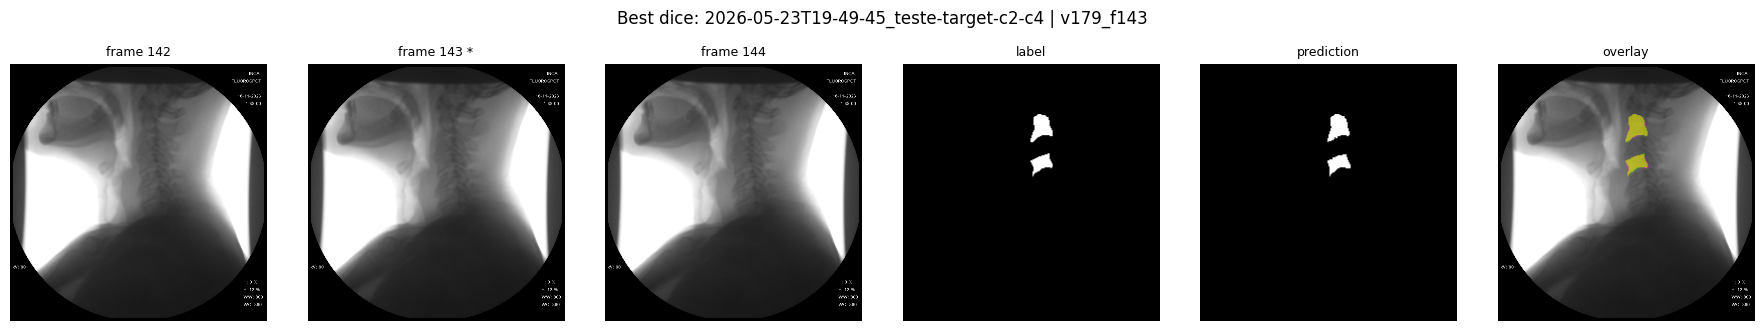

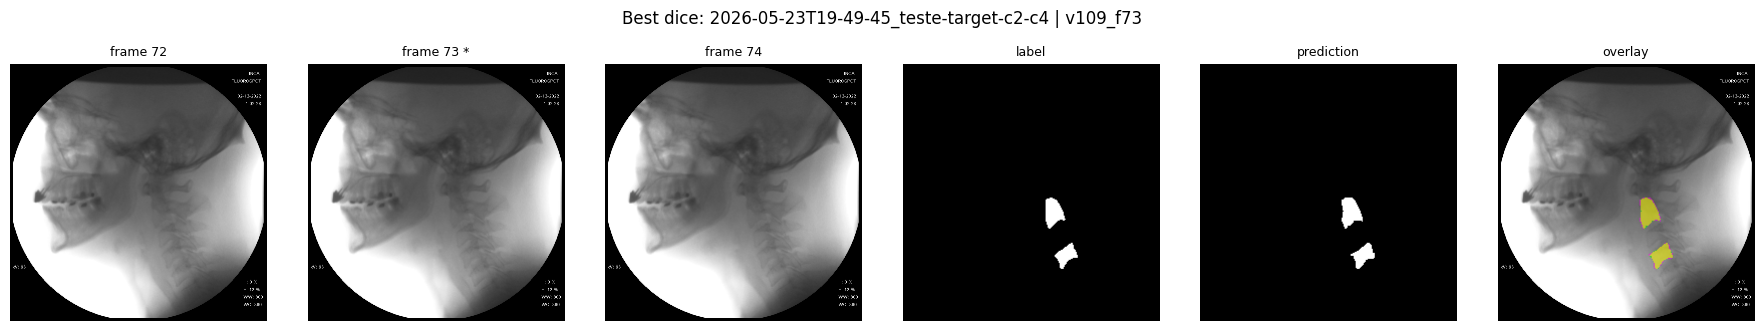

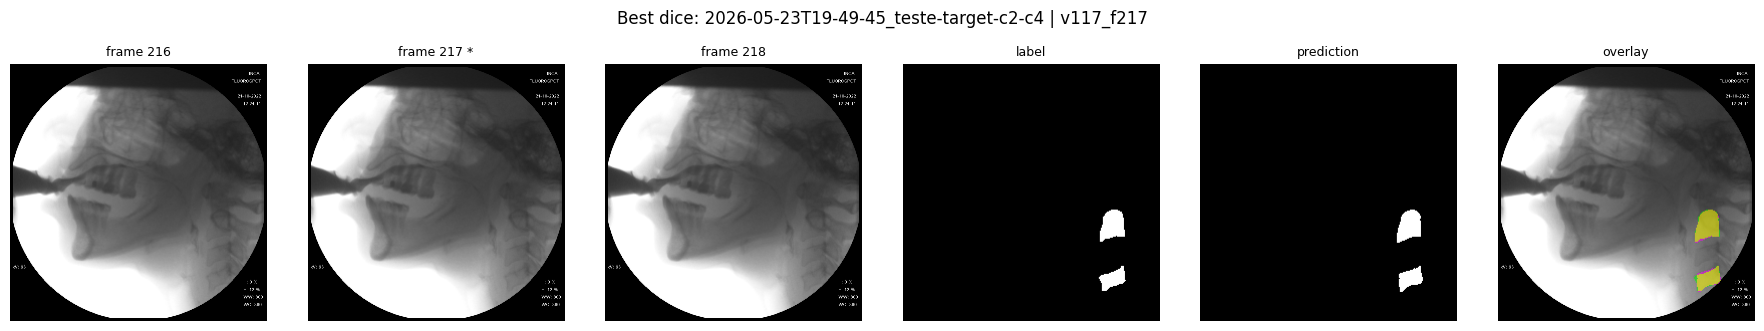

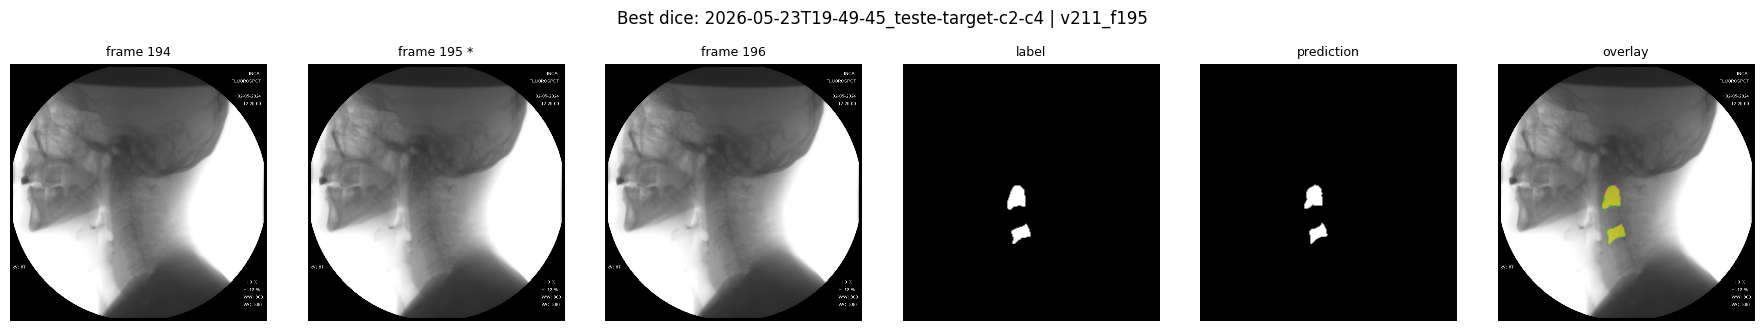

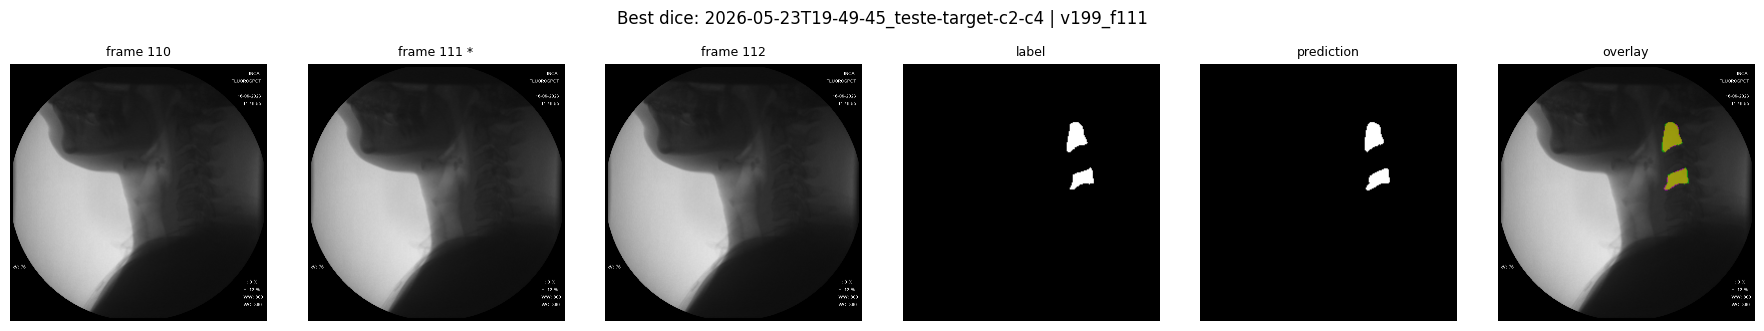

### Worst dice: 2026-05-23T19-49-45_teste-target-c2-c4

,sample_id,video_id,frame_id,window_frame_ids,dice,iou,pred_area,label_area
67,v205_f138,205,138,"[137, 138, 139]",0.593977,0.422452,577,1349
130,v59_f102,59,102,"[101, 102, 103]",0.623068,0.452504,282,559
131,v59_f158,59,158,"[157, 158, 159]",0.633615,0.463717,304,523
103,v27_f68,27,68,"[67, 68, 69]",0.658581,0.490958,545,1104
68,v205_f221,205,221,"[220, 221, 222]",0.659420,0.491892,640,1292


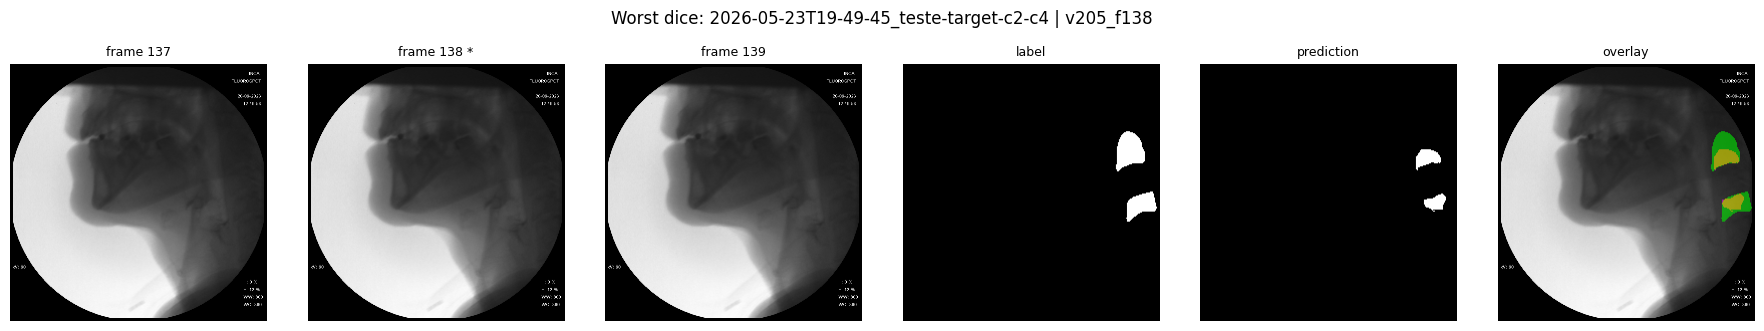

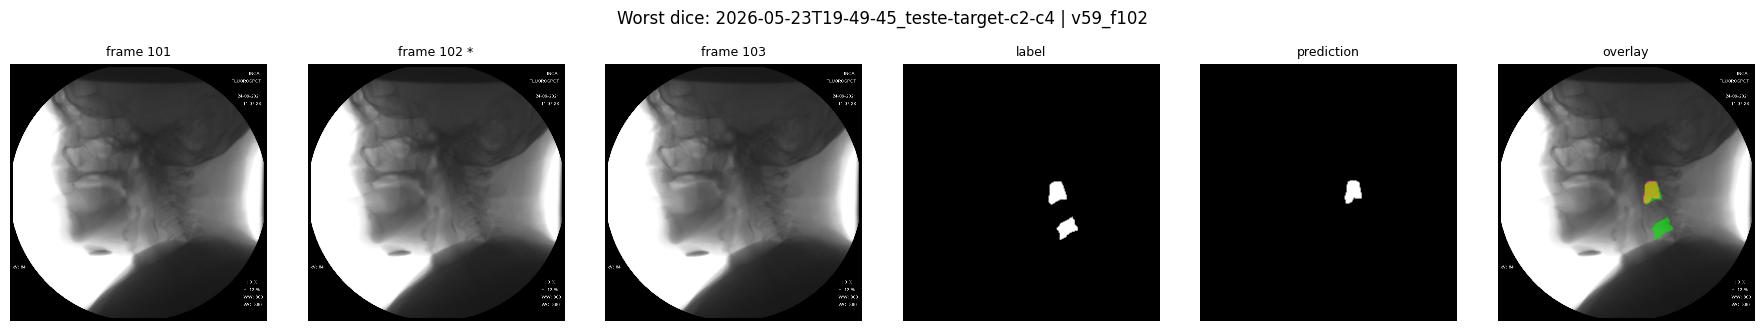

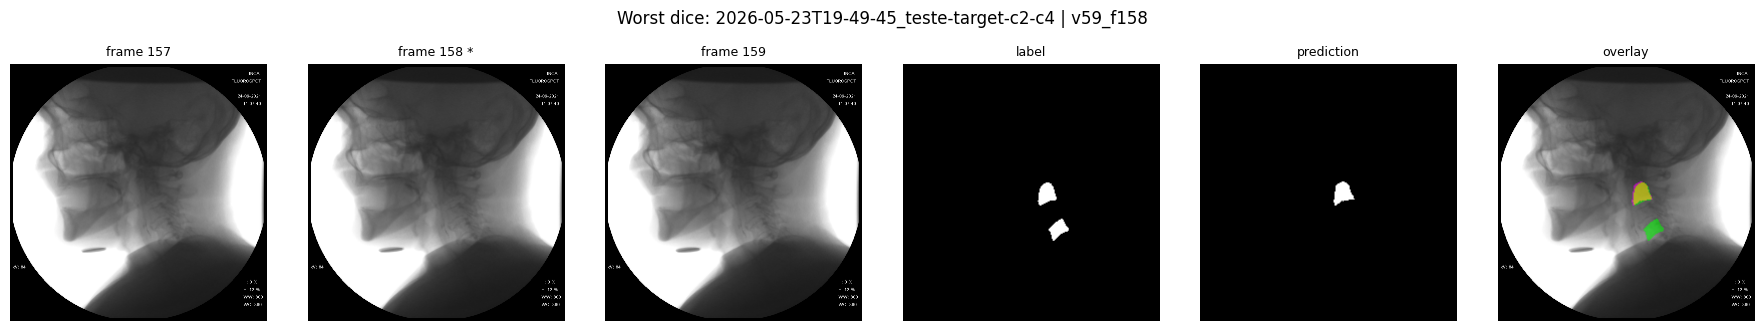

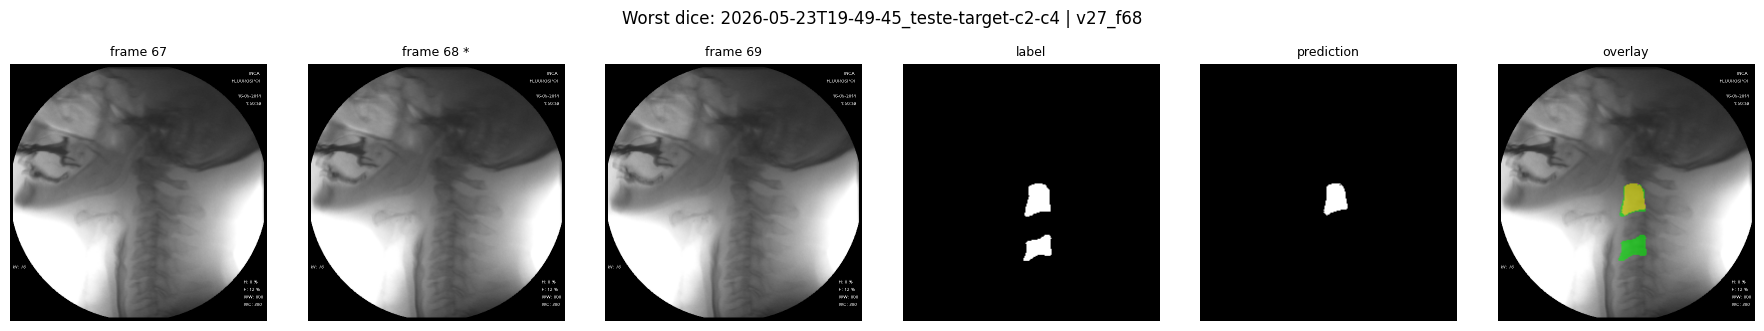

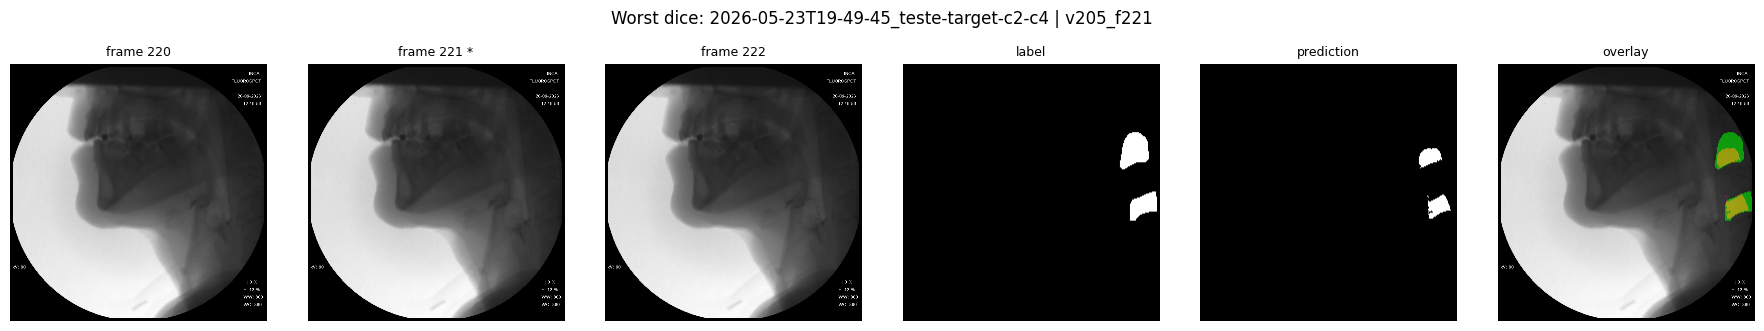

### Best dice: 2026-05-12T20-08-54_vfss-new-inca-window-3

,sample_id,video_id,frame_id,window_frame_ids,dice,iou,pred_area,label_area
222,v199_f111,199,111,"[110, 111, 112]",0.938882,0.884804,1503,1573
219,v196_f37,196,37,"[36, 37, 38]",0.938472,0.884076,1480,1478
234,v210_f141,210,141,"[140, 141, 142]",0.937709,0.882723,2605,2789
246,v234_f12,234,12,"[11, 12, 13]",0.937576,0.882488,1622,1646
166,v117_f186,117,186,"[185, 186, 187]",0.937523,0.882393,1318,1419


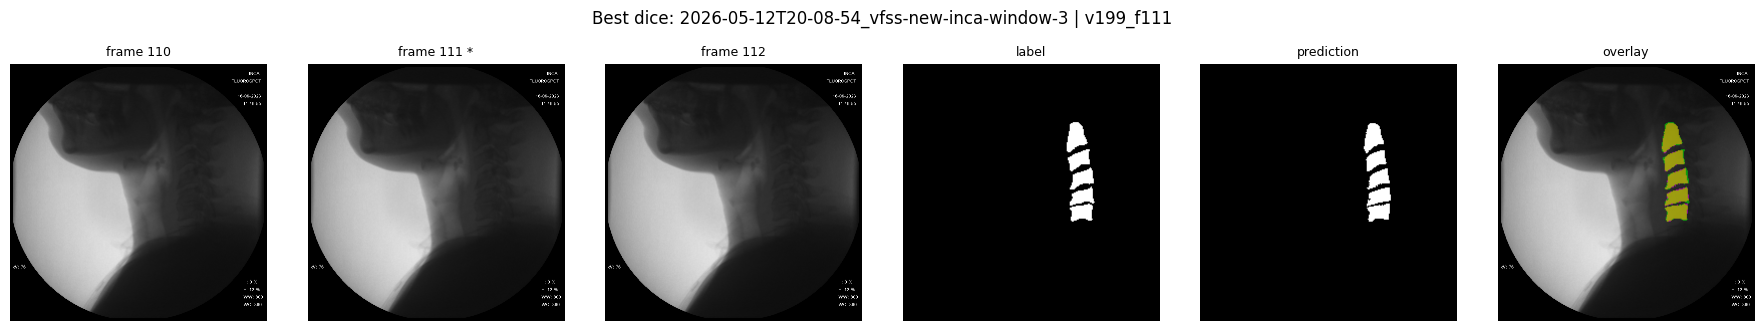

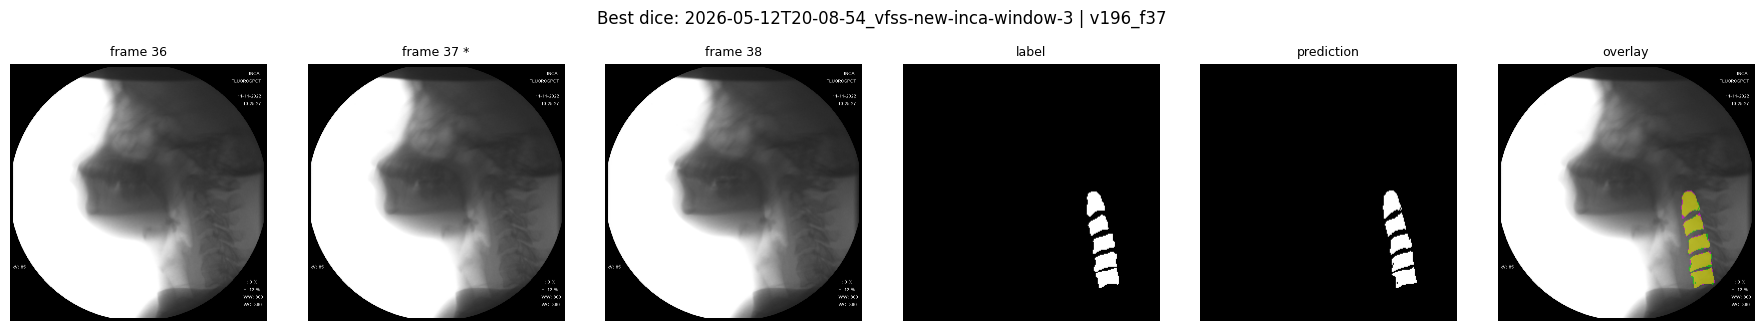

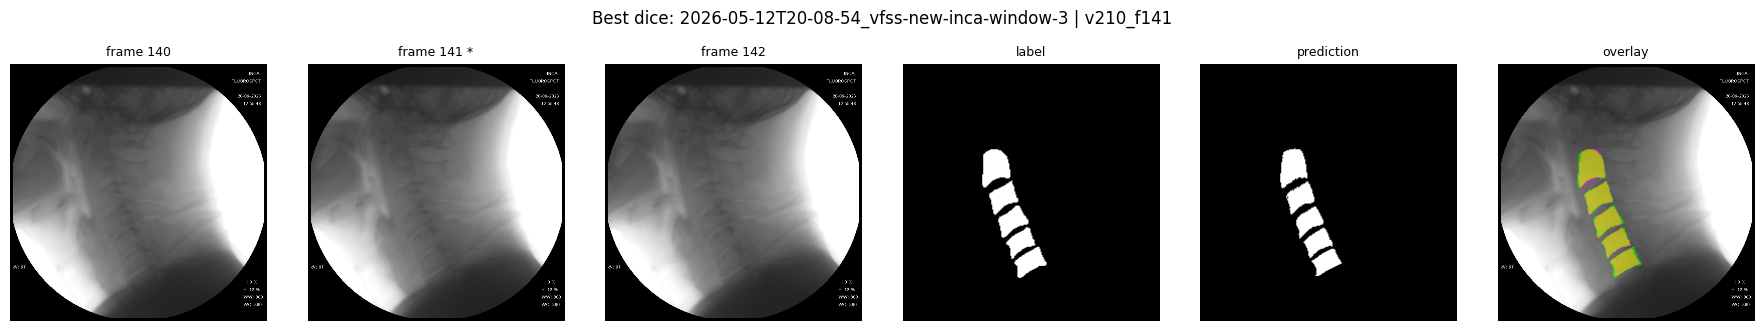

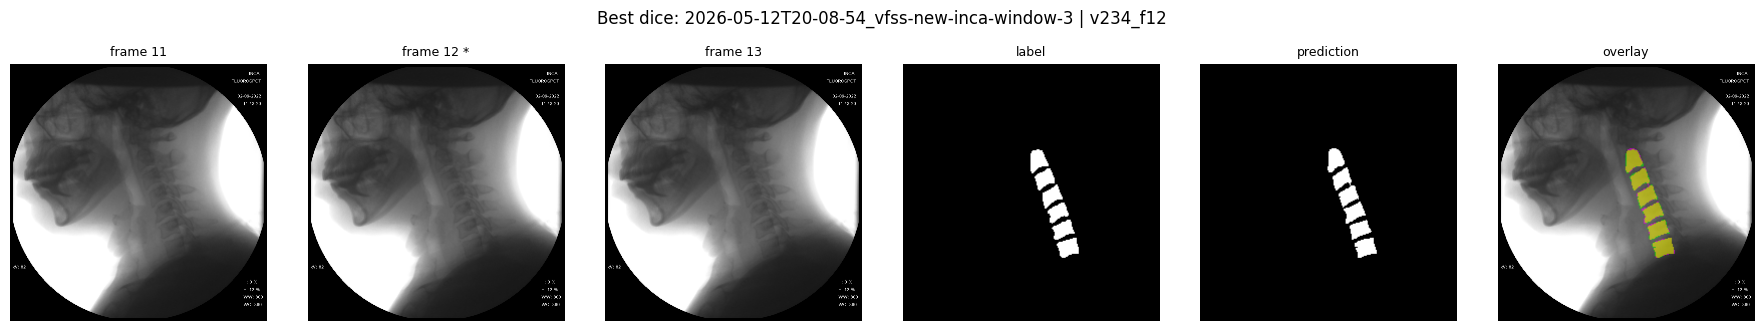

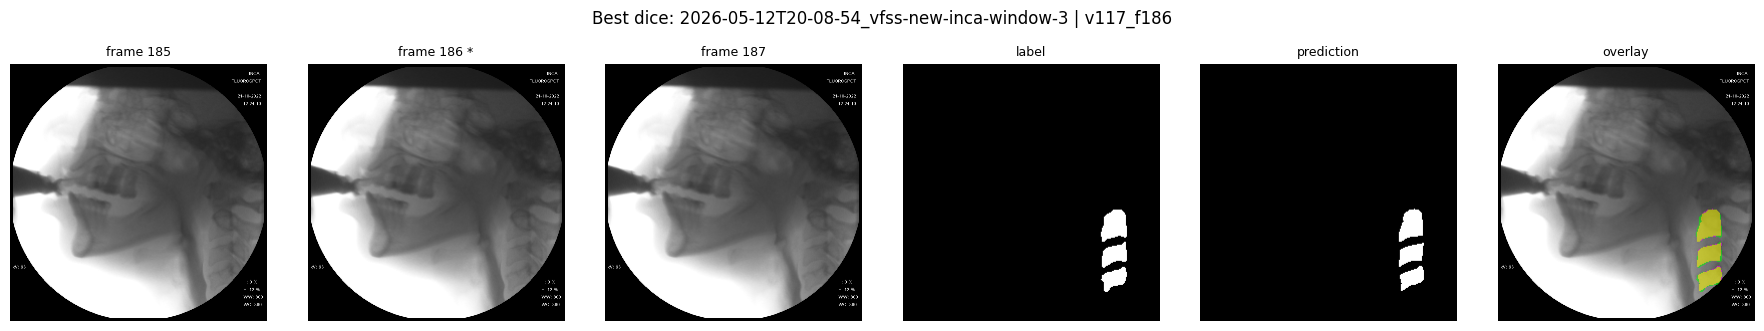

### Worst dice: 2026-05-12T20-08-54_vfss-new-inca-window-3

,sample_id,video_id,frame_id,window_frame_ids,dice,iou,pred_area,label_area
311,v86_f155,86,155,"[154, 155, 156]",0.628481,0.458238,933,970
313,v86_f2,86,2,"[1, 2, 3]",0.701166,0.539842,879,1266
176,v11_f41,11,41,"[40, 41, 42]",0.708297,0.548343,1390,900
235,v210_f43,210,43,"[42, 43, 44]",0.710789,0.551337,2363,3439
248,v234_f188,234,188,"[187, 188, 189]",0.723958,0.567347,1701,987


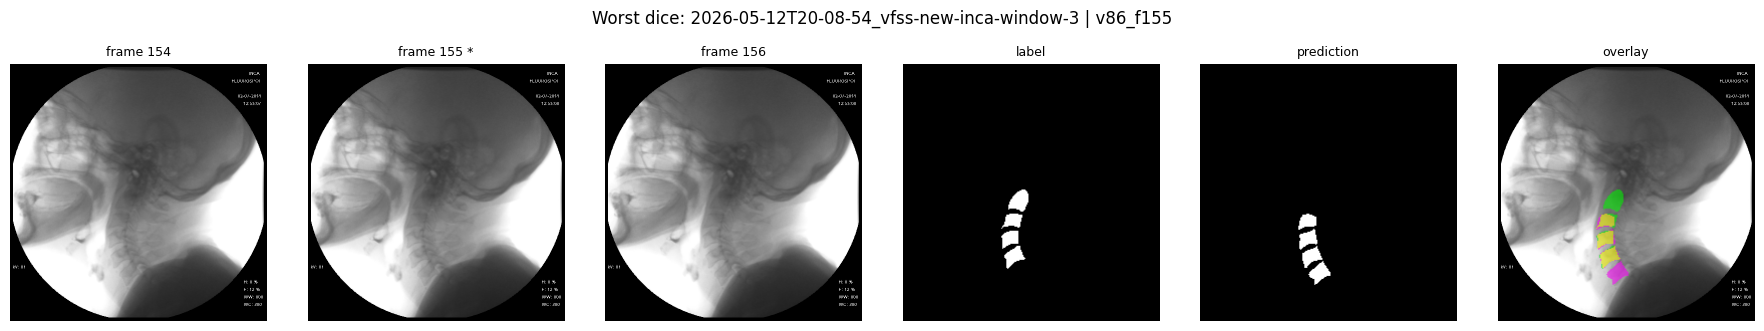

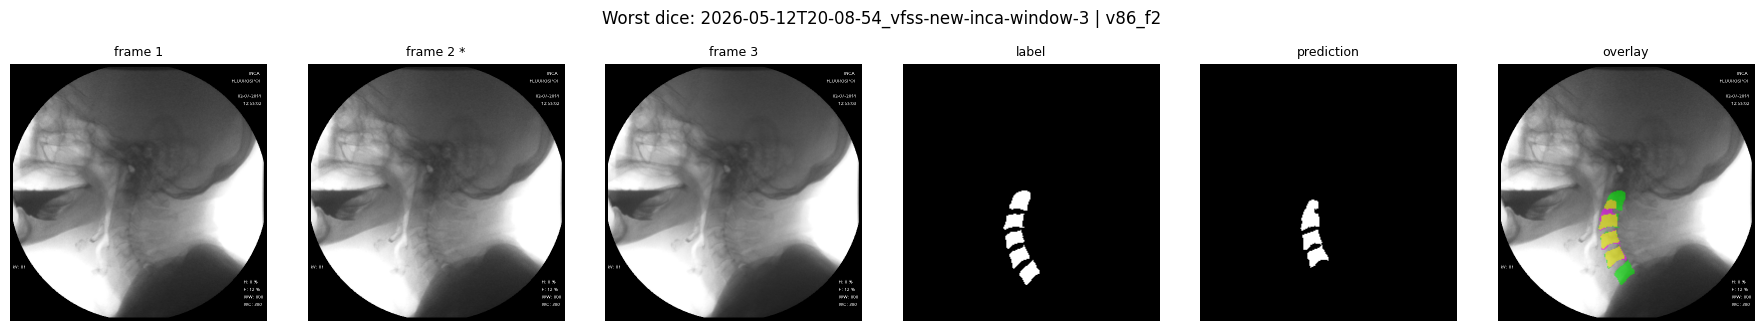

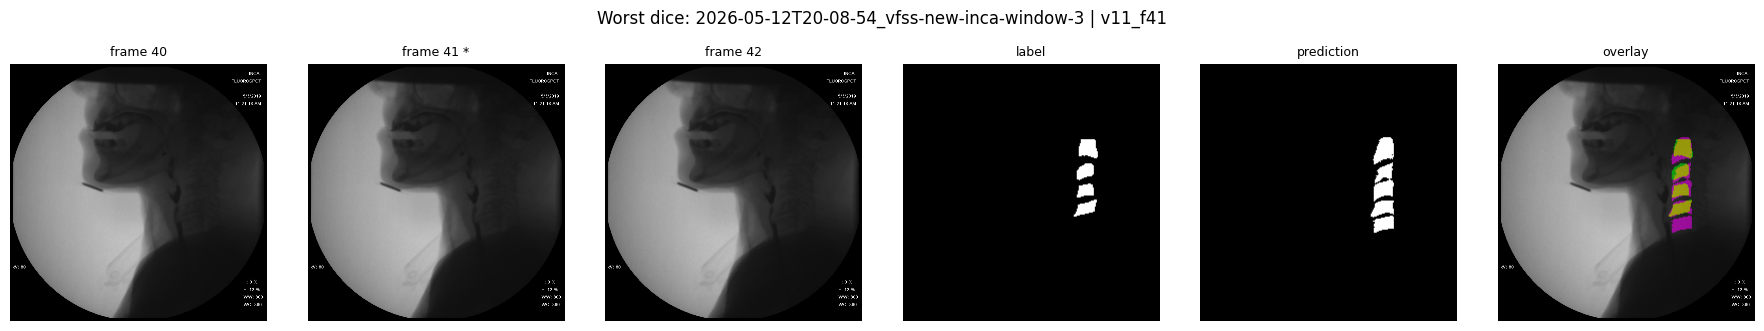

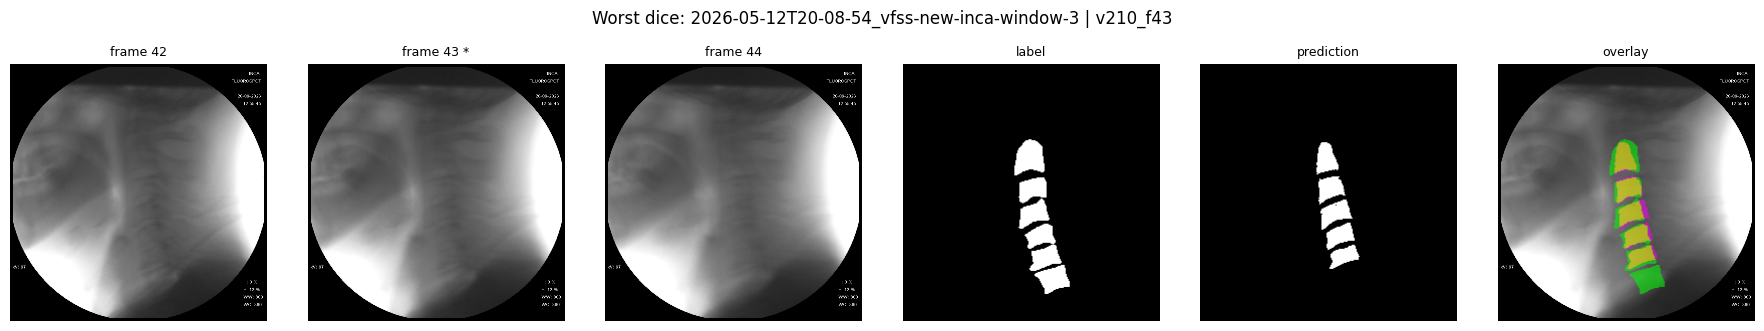

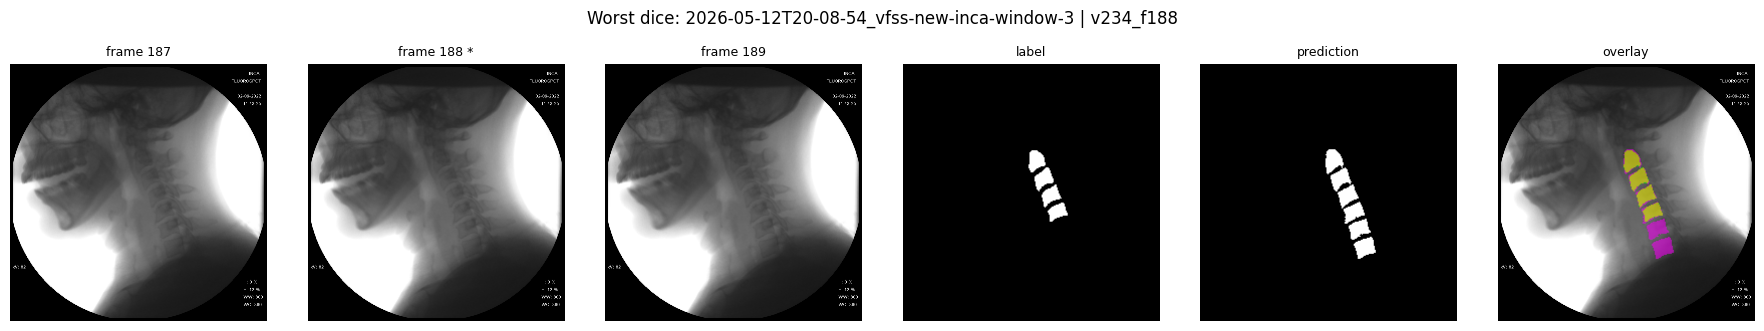

In [9]:
for experiment_name in notebook_config["experiment_names"]:
    plot_ranked_cases(
        metrics_df,
        results_by_experiment,
        experiment_name,
        metric=notebook_config["comparison_metric"],
        top_k=notebook_config["top_k"],
    )

## What improved and what got worse?

These plots compare the same test examples across the two experiments. If one model has a temporal window and the other does not, the temporal model row shows every frame from its window so you can inspect whether neighboring frames explain the metric change.

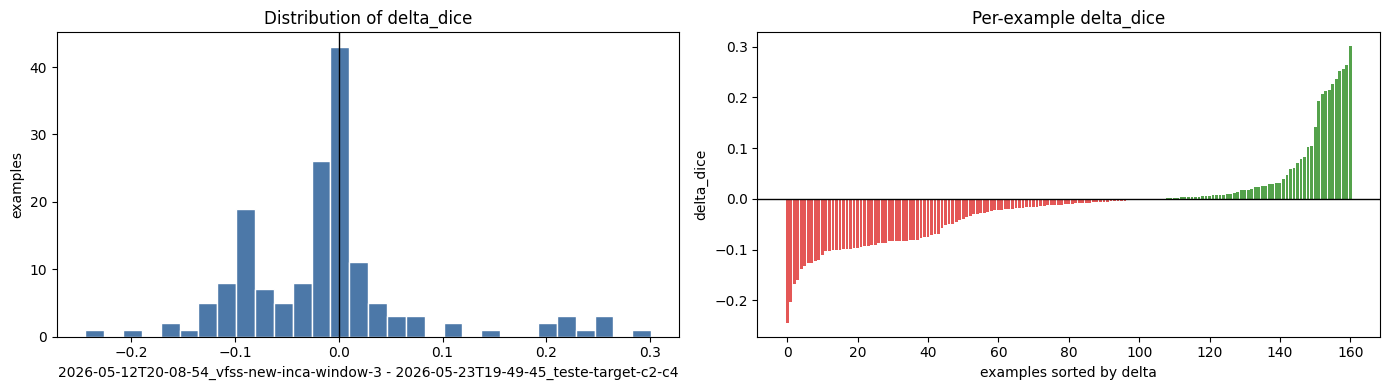

### Most improved by dice

,sample_id,video_id,frame_id,selected_labeler,dice_2026-05-23T19-49-45_teste-target-c2-c4,dice_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_dice,label_area
130,v59_f102,59,102,VR,0.623068,0.924138,0.301070,559
131,v59_f158,59,158,VR,0.633615,0.897172,0.263557,523
154,v89_f118,89,118,VC,0.662829,0.917966,0.255137,753
107,v30_f80,30,80,CS,0.685327,0.937207,0.251881,759
105,v30_f15,30,15,AM,0.667208,0.904476,0.237268,781


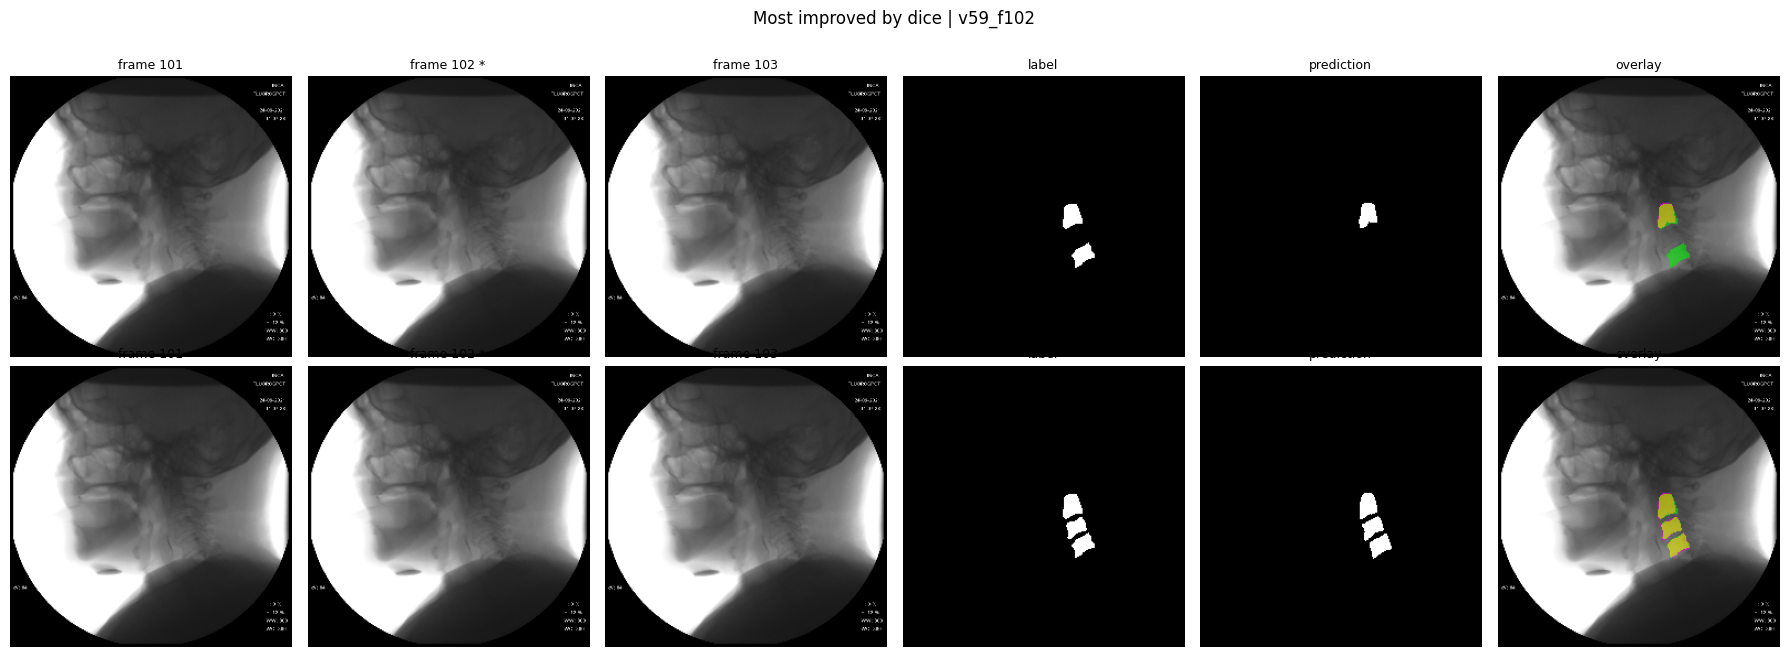

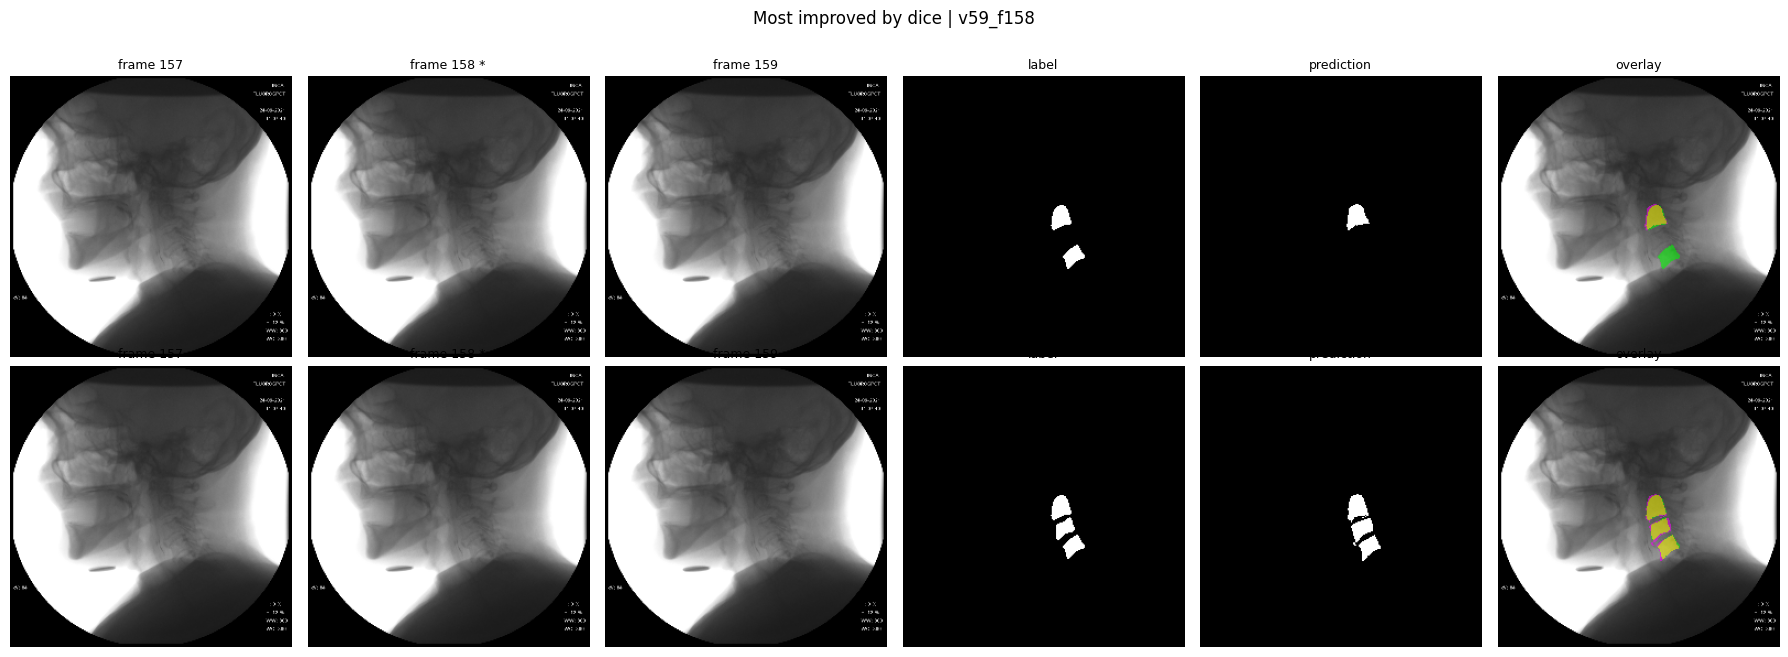

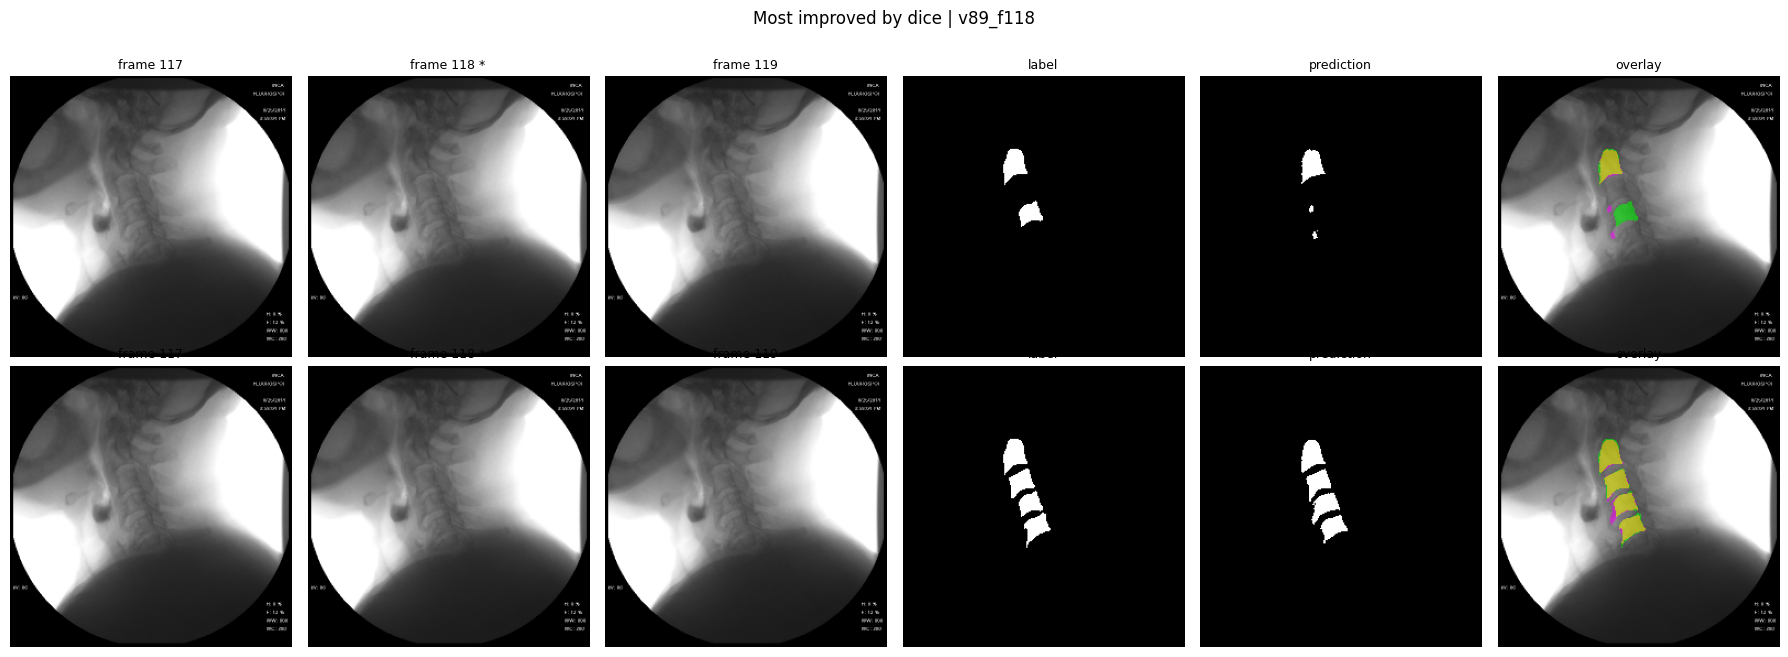

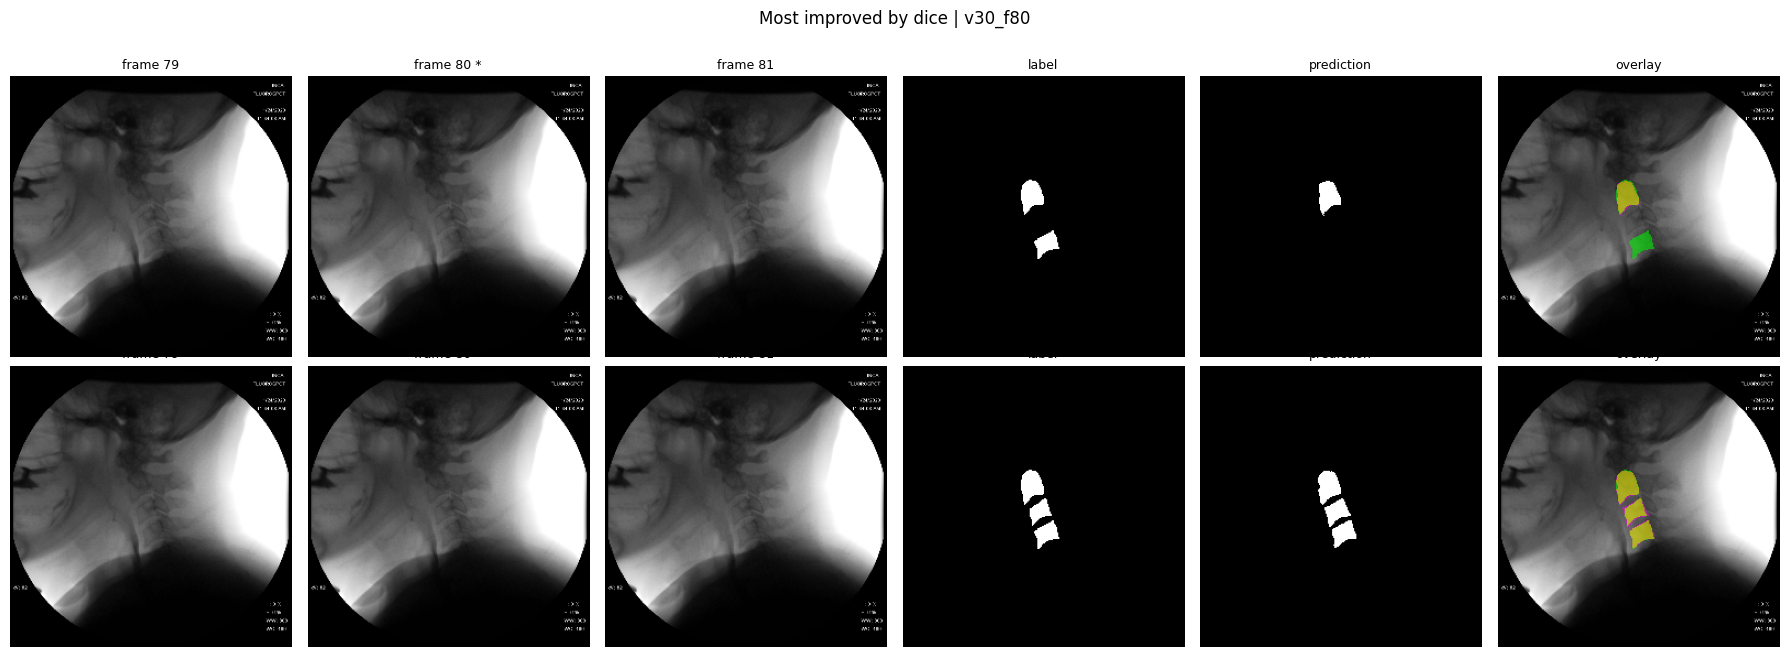

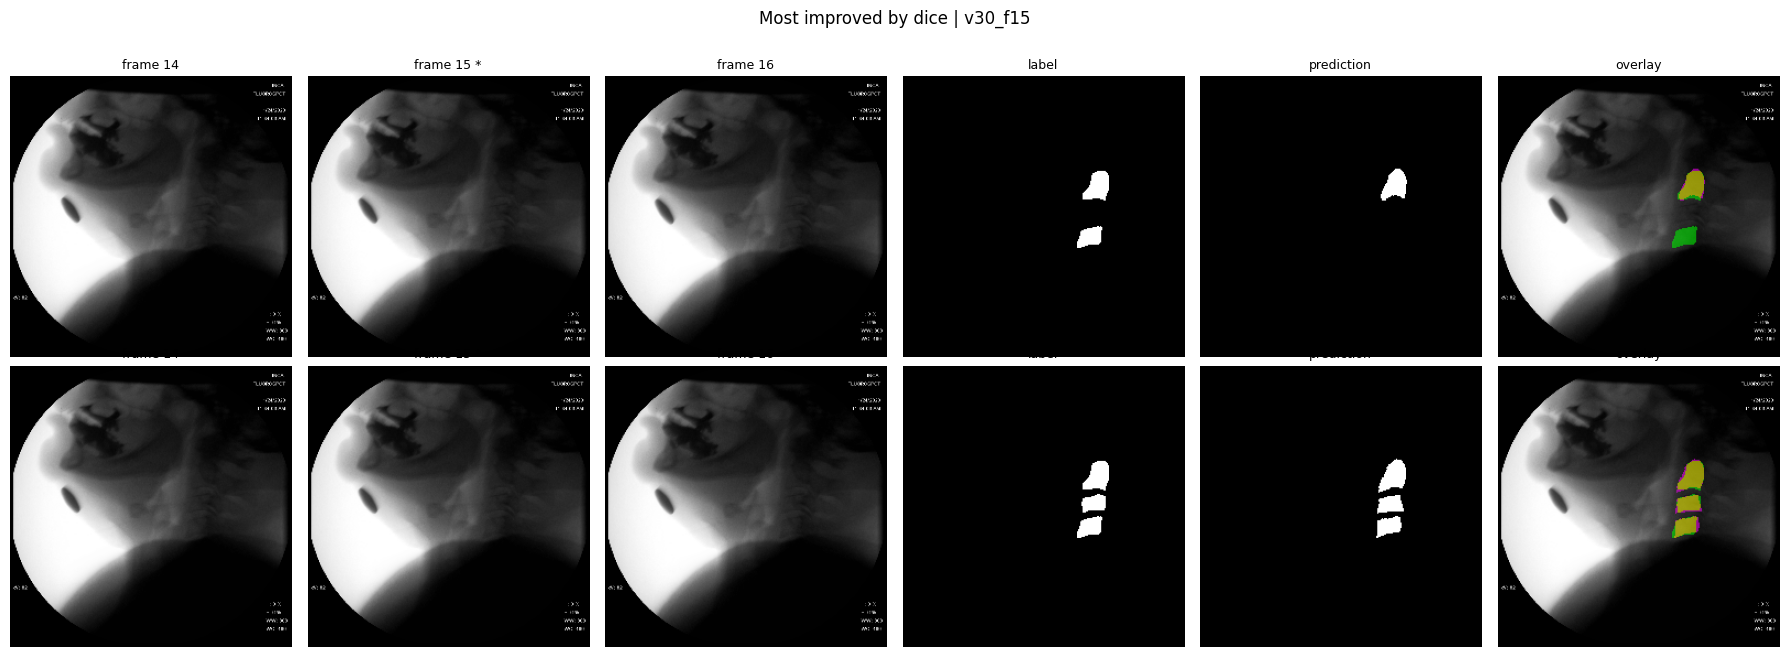

### Most worse by dice

,sample_id,video_id,frame_id,selected_labeler,dice_2026-05-23T19-49-45_teste-target-c2-c4,dice_2026-05-12T20-08-54_vfss-new-inca-window-3,delta_dice,label_area
150,v86_f155,86,155,BB,0.872906,0.628481,-0.244425,520
87,v234_f188,234,188,BB,0.926641,0.723958,-0.202683,501
25,v131_f11,131,11,VC,0.920398,0.751768,-0.168630,629
92,v23_f134,23,134,VC,0.905080,0.745202,-0.159878,785
152,v86_f2,86,2,VR,0.838649,0.701166,-0.137484,524


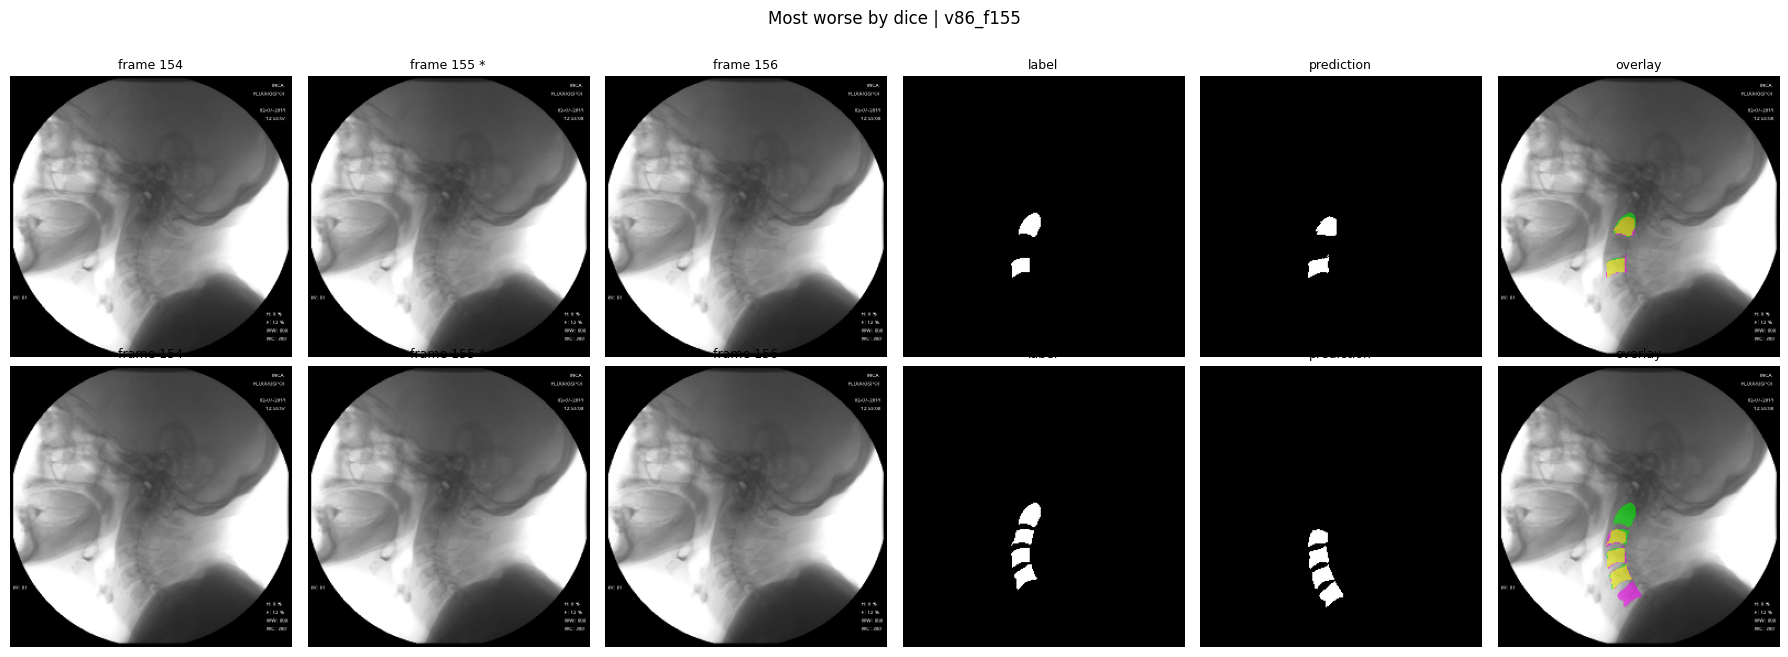

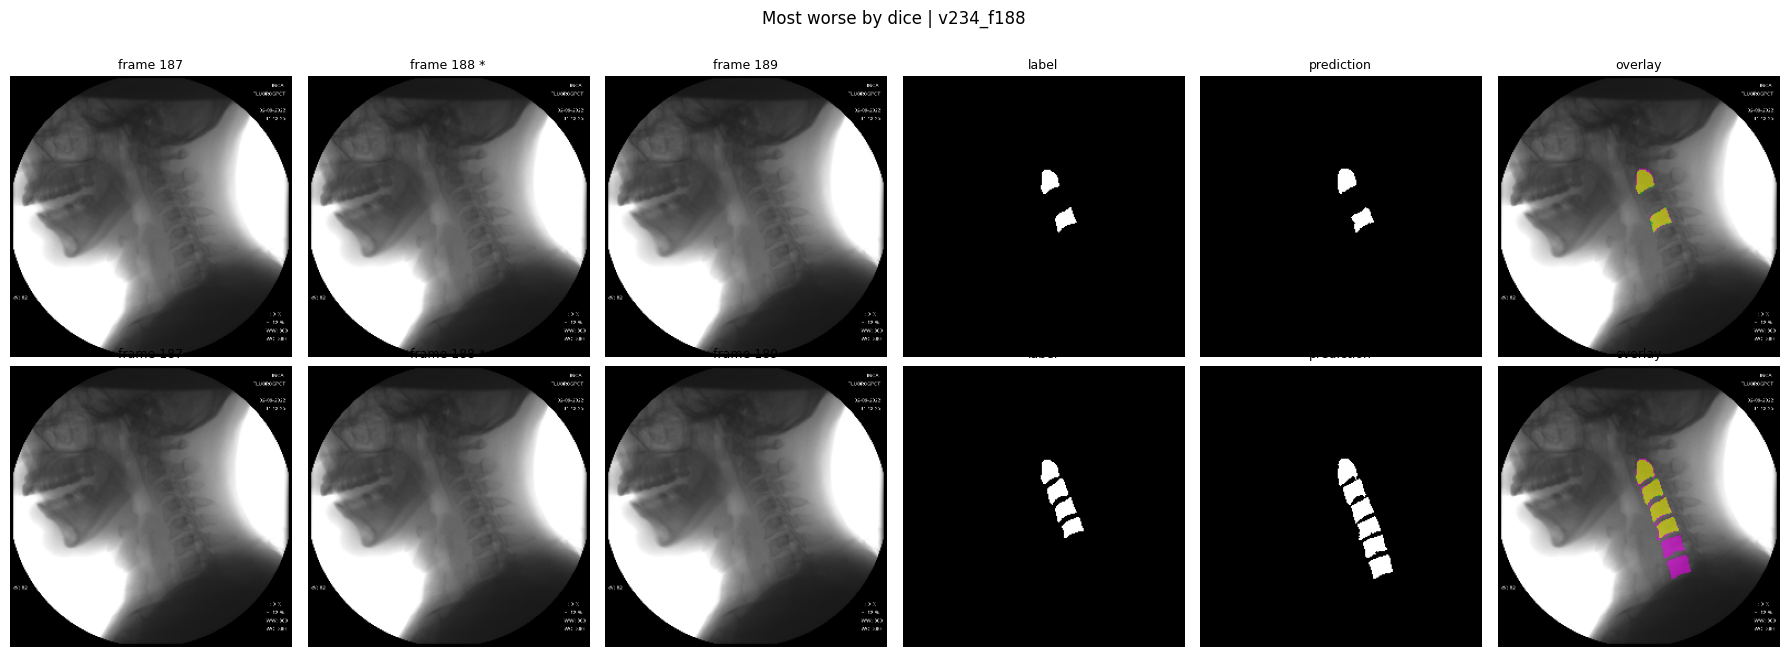

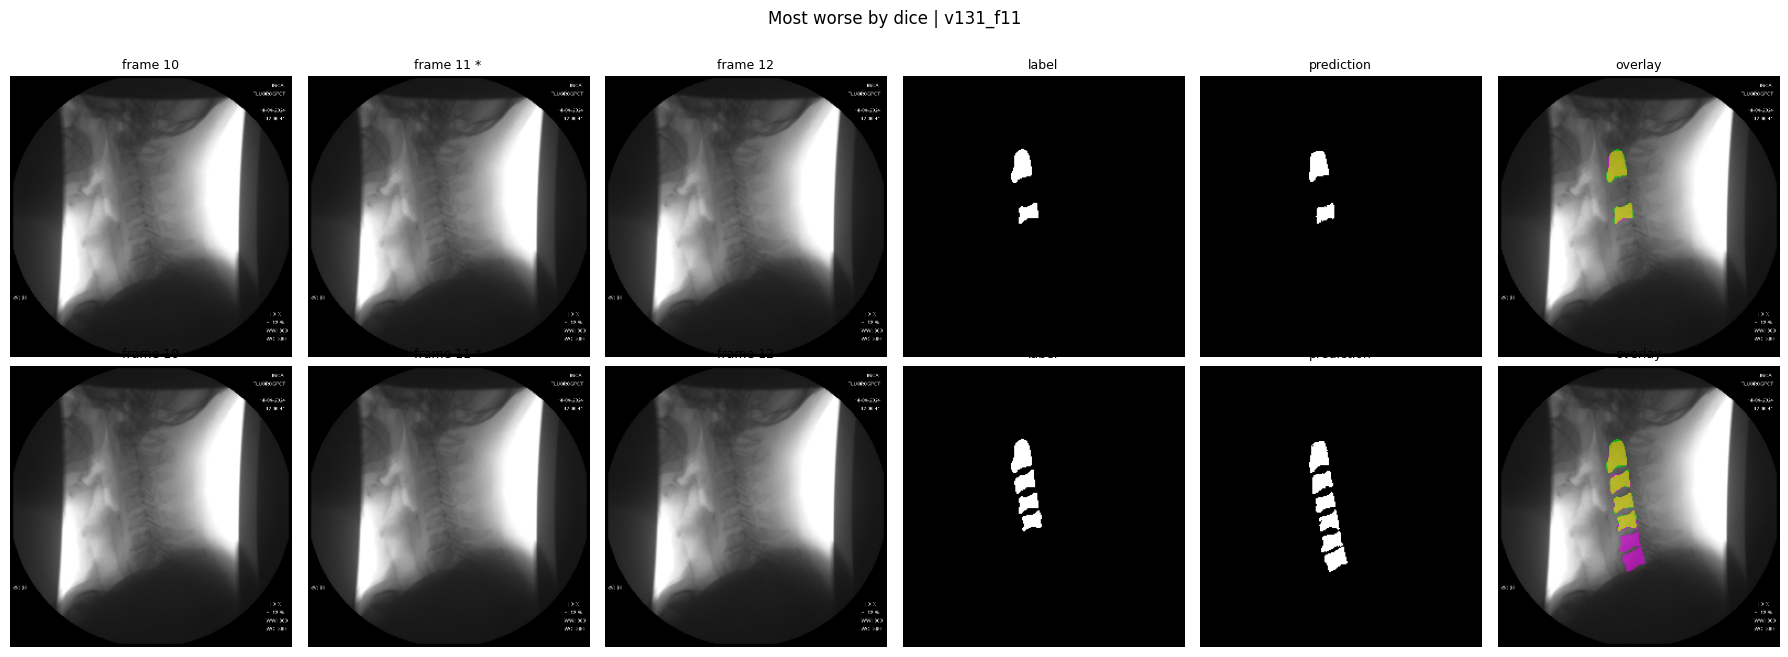

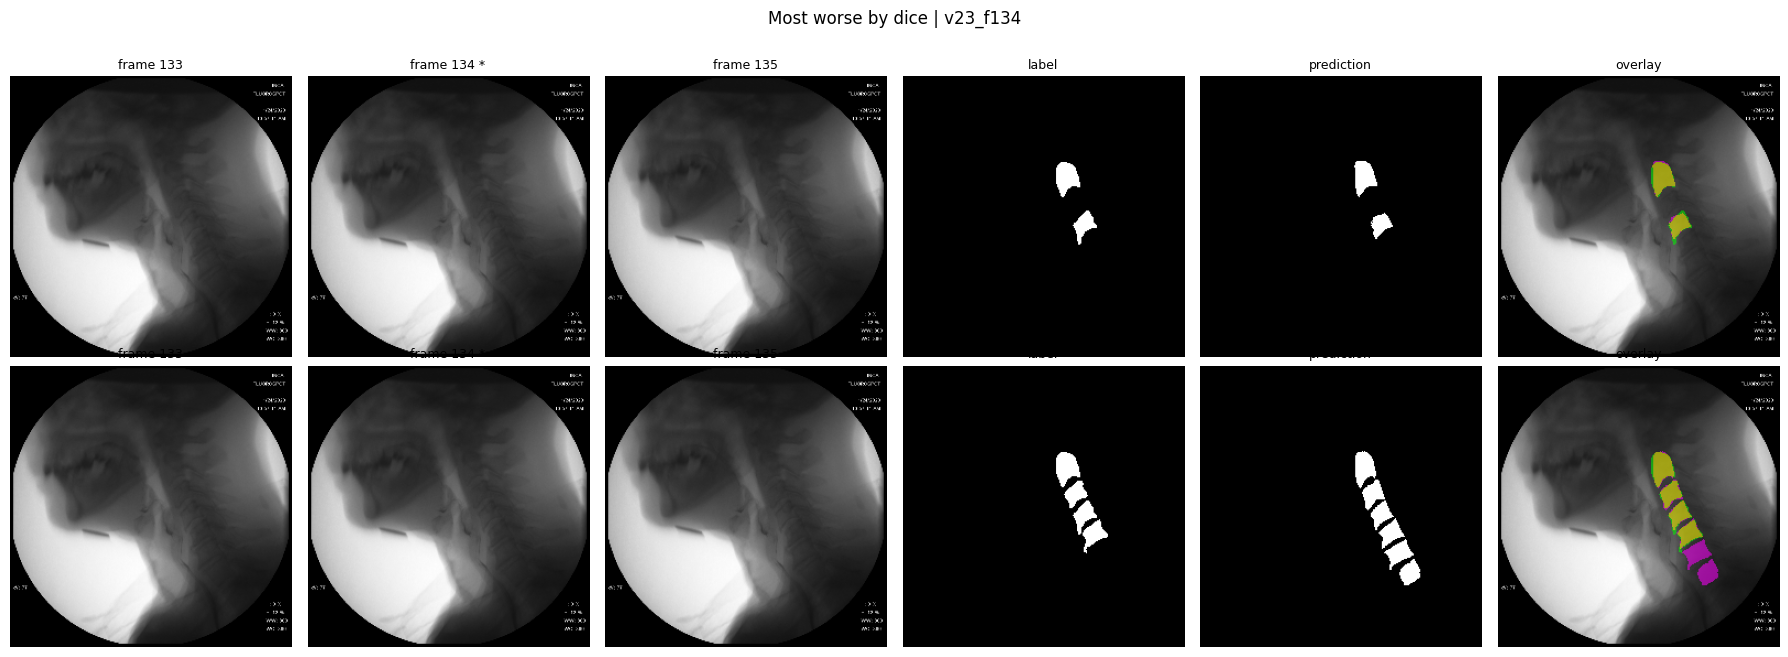

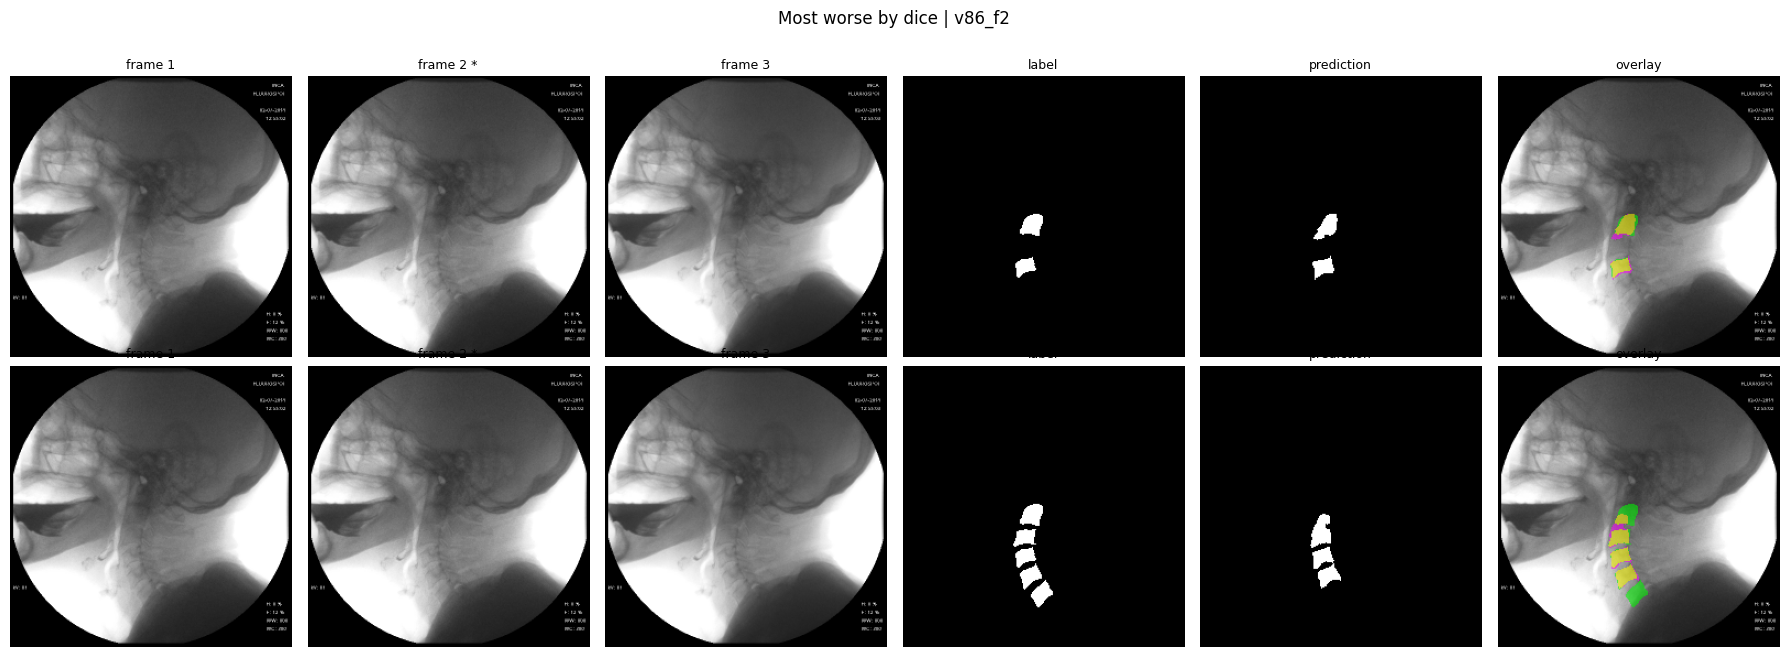

In [10]:
metric = notebook_config["comparison_metric"]
delta_col = f"delta_{metric}"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(comparison_df[delta_col].dropna(), bins=30, color="#4c78a8", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Distribution of {delta_col}")
axes[0].set_xlabel(f"{candidate_exp} - {base_exp}")
axes[0].set_ylabel("examples")

ordered = comparison_df.sort_values(delta_col)
axes[1].bar(np.arange(len(ordered)), ordered[delta_col], color=np.where(ordered[delta_col] >= 0, "#54a24b", "#e45756"))
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"Per-example {delta_col}")
axes[1].set_xlabel("examples sorted by delta")
axes[1].set_ylabel(delta_col)
plt.tight_layout()
plt.show()

plot_comparison_cases(
    comparison_df,
    results_by_experiment,
    metric=metric,
    top_k=notebook_config["top_k"],
)

## Additional analysis tables

Use these summaries to look for systematic changes by video, labeler, mask size, or prediction area. They are useful when a temporal model improves specific motion contexts but regresses on small masks or ambiguous frames.

In [11]:
metric = notebook_config["comparison_metric"]
delta_col = f"delta_{metric}"

analysis_df = comparison_df.copy()
analysis_df["change_type"] = np.select(
    [analysis_df[delta_col] > 0, analysis_df[delta_col] < 0],
    ["improved", "worse"],
    default="unchanged",
)
analysis_df["label_area_bin"] = pd.qcut(
    analysis_df["label_area"].rank(method="first"),
    q=min(4, analysis_df["label_area"].nunique()),
    labels=False,
    duplicates="drop",
)

by_change = (
    analysis_df.groupby("change_type")
    .agg(
        examples=("sample_id", "count"),
        mean_delta=(delta_col, "mean"),
        median_delta=(delta_col, "median"),
        mean_label_area=("label_area", "mean"),
        mean_delta_pred_area=("delta_pred_area", "mean"),
    )
    .sort_values("mean_delta", ascending=False)
)

by_video = (
    analysis_df.groupby("video_id")
    .agg(
        examples=("sample_id", "count"),
        mean_delta=(delta_col, "mean"),
        improved=("change_type", lambda values: (values == "improved").sum()),
        worse=("change_type", lambda values: (values == "worse").sum()),
    )
    .sort_values("mean_delta", ascending=False)
)

by_labeler = (
    analysis_df.groupby("selected_labeler", dropna=False)
    .agg(
        examples=("sample_id", "count"),
        mean_delta=(delta_col, "mean"),
        median_delta=(delta_col, "median"),
        improved=("change_type", lambda values: (values == "improved").sum()),
        worse=("change_type", lambda values: (values == "worse").sum()),
    )
    .sort_values("mean_delta", ascending=False)
)

by_mask_size = (
    analysis_df.groupby("label_area_bin", dropna=False)
    .agg(
        examples=("sample_id", "count"),
        mean_delta=(delta_col, "mean"),
        median_delta=(delta_col, "median"),
        mean_label_area=("label_area", "mean"),
    )
)

display(Markdown("### Change type summary"))
display(by_change)
display(Markdown("### Videos with largest average improvement"))
display(by_video.head(10))
display(Markdown("### Videos with largest average regression"))
display(by_video.tail(10))
display(Markdown("### Labeler summary"))
display(by_labeler)
display(Markdown("### Mask-size summary"))
display(by_mask_size)

### Change type summary

,examples,mean_delta,median_delta,mean_label_area,mean_delta_pred_area
change_type,,,,,
improved,57,0.062512,0.019177,784.596491,813.631579
worse,104,-0.053930,-0.035408,701.759615,765.817308


### Videos with largest average improvement

,examples,mean_delta,improved,worse
video_id,,,,
59,2,0.282313,2,0
30,4,0.196107,4,0
67,3,0.074495,2,1
89,4,0.071482,3,1
229,1,0.069660,1,0
205,4,0.066461,3,1
35,4,0.063799,2,2
72,4,0.034976,2,2
27,4,0.025110,2,2


### Videos with largest average regression

,examples,mean_delta,improved,worse
video_id,,,,
180,4,-0.063638,0,4
4,4,-0.065313,0,4
179,3,-0.068117,0,3
23,4,-0.070242,1,3
127,5,-0.072632,0,5
218,3,-0.083344,0,3
164,3,-0.084916,0,3
120,4,-0.091763,0,4
211,2,-0.108440,0,2


### Labeler summary

,examples,mean_delta,median_delta,improved,worse
selected_labeler,,,,,
AM,5,0.075302,-0.016216,2,3
VR,17,0.028366,0.000213,9,8
CS,22,-0.002498,-0.006745,10,12
VC,99,-0.023864,-0.012936,28,71
BB,18,-0.027048,-0.004118,8,10


### Mask-size summary

,examples,mean_delta,median_delta,mean_label_area
label_area_bin,,,,
0,41,-0.027837,-0.024139,535.317073
1,40,-0.023585,-0.013969,636.025000
2,40,-0.013643,-0.011696,722.575000
3,40,0.014622,0.004129,1035.325000


## Data-driven notes

Run this cell after the analysis tables to print a compact narrative summary. Use the plotted temporal frames above to validate whether neighboring frames seem to help or hurt in the largest deltas.

In [12]:
metric = notebook_config["comparison_metric"]
delta_col = f"delta_{metric}"

mean_delta = comparison_df[delta_col].mean()
median_delta = comparison_df[delta_col].median()
improved = int((comparison_df[delta_col] > 0).sum())
worse = int((comparison_df[delta_col] < 0).sum())
unchanged = int((comparison_df[delta_col] == 0).sum())
best_row = comparison_df.loc[comparison_df[delta_col].idxmax()]
worst_row = comparison_df.loc[comparison_df[delta_col].idxmin()]

notes = f"""
### Summary

Comparing `{candidate_exp}` against `{base_exp}` on `{len(comparison_df)}` matched test examples:

- Mean delta `{metric}`: `{mean_delta:.4f}`; median delta: `{median_delta:.4f}`.
- Improved examples: `{improved}`; worse examples: `{worse}`; unchanged examples: `{unchanged}`.
- Largest improvement: `{best_row['sample_id']}` with delta `{best_row[delta_col]:.4f}`.
- Largest regression: `{worst_row['sample_id']}` with delta `{worst_row[delta_col]:.4f}`.

Interpretation checklist:

- Inspect the most-improved plots for label motion, blur, bolus continuity, or clearer structure in adjacent frames.
- Inspect the most-worse plots for cases where adjacent frames may introduce stale location context, boundary ambiguity, or false positives.
- Compare `delta_pred_area` with overlays: large positive area deltas often indicate the candidate predicts more foreground; large negative deltas often indicate missed mask regions.
"""

display(Markdown(notes))


### Summary

Comparing `2026-05-12T20-08-54_vfss-new-inca-window-3` against `2026-05-23T19-49-45_teste-target-c2-c4` on `161` matched test examples:

- Mean delta `dice`: `-0.0127`; median delta: `-0.0105`.
- Improved examples: `57`; worse examples: `104`; unchanged examples: `0`.
- Largest improvement: `v59_f102` with delta `0.3011`.
- Largest regression: `v86_f155` with delta `-0.2444`.

Interpretation checklist:

- Inspect the most-improved plots for label motion, blur, bolus continuity, or clearer structure in adjacent frames.
- Inspect the most-worse plots for cases where adjacent frames may introduce stale location context, boundary ambiguity, or false positives.
- Compare `delta_pred_area` with overlays: large positive area deltas often indicate the candidate predicts more foreground; large negative deltas often indicate missed mask regions.
